In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings

warnings.filterwarnings('ignore')

# --- Fungsi-fungsi Utama ---

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords')
        nltk.download('punkt')
        print("Download selesai.")

def load_and_clean_data(filepath):
    """Memuat data dari CSV, membersihkan, dan mengekstrak label sentimen."""
    print("\nTahap 1: Memuat dan Membersihkan Data...")
    df = pd.read_csv(filepath, delimiter=';')

    def get_first_polarity(sentiment_list_str):
        try:
            sentiment_list = ast.literal_eval(sentiment_list_str)
            if isinstance(sentiment_list, list) and len(sentiment_list) > 0:
                return sentiment_list[0].get('polarity', 'neutral')
        except (ValueError, SyntaxError):
            return 'neutral'
        return 'neutral'

    df['polarity'] = df['aspect_term_sentiment'].apply(get_first_polarity)
    df_filtered = df[df['polarity'] != 'neutral'].copy()
    label_mapping = {'positive': 1, 'negative': 0}
    df_filtered['label'] = df_filtered['polarity'].map(label_mapping)
    df_filtered.dropna(subset=['review', 'label'], inplace=True)
    df_filtered['label'] = df_filtered['label'].astype(int)
    print(f"Data berhasil dimuat. Jumlah ulasan setelah filter: {len(df_filtered)}")
    return df_filtered

def visualize_eda(df):
    """Membuat dan menyimpan visualisasi distribusi sentimen."""
    print("\nMembuat visualisasi distribusi sentimen...")
    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    ax = sns.countplot(x='polarity', data=df, palette=['#2ecc71', '#e74c3c'], order=['positive', 'negative'])
    plt.title('Distribusi Sentimen Ulasan Produk', fontsize=16)
    plt.xlabel('Sentimen', fontsize=12)
    plt.ylabel('Jumlah Ulasan', fontsize=12)
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
    plt.savefig('1_sentiment_distribution.png')
    plt.close()
    print("Visualisasi disimpan sebagai '1_sentiment_distribution.png'")

def preprocess_text_data(df):
    """Melakukan pra-pemrosesan teks yang komprehensif."""
    print("\nTahap 2: Pra-pemrosesan Teks...")
    slang_dict = {
        'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'gk': 'tidak', 'krn': 'karena', 
        'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 
        'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 
        'bikin': 'membuat', 'jg': 'juga', 'jgn': 'jangan', 'kayak': 'seperti', 'kyk': 'seperti', 'nih': 'ini', 
        'sih': 'sih', 'gue': 'saya', 'gw': 'saya', 'lu': 'kamu', 'lo': 'kamu', 'bangettt': 'banget', 
        'bgttt': 'banget', 'sunscreeen': 'sunscreen', 'suncreen': 'sunscreen', 'jujurly':'jujur', 'tp': 'tapi', 
        'tdk': 'tidak', 'bgtu': 'begitu', 'bangetttt':'banget', 'ngl': 'sejujurnya', 'a!!':'a', 'omg':'ya tuhan',
        'omaigat':'ya tuhan'
    }
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [stemmer.stem(slang_dict.get(word, word)) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['cleaned_review'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def visualize_wordclouds(df):
    """Membuat dan menyimpan word cloud sebelum dan sesudah pra-pemrosesan."""
    print("\nTahap 3: Membuat Visualisasi Word Cloud...")
    text_before = " ".join(review for review in df.review)
    wordcloud_before = WordCloud(width=800, height=400, background_color="white").generate(text_before)
    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud_before, interpolation='bilinear')
    plt.axis("off"); plt.title("Word Cloud Sebelum Pra-pemrosesan", fontsize=16); plt.savefig("2_wordcloud_before.png"); plt.close()

    text_after = " ".join(review for review in df.cleaned_review if review)
    if text_after:
        wordcloud_after = WordCloud(width=800, height=400, background_color="white").generate(text_after)
        plt.figure(figsize=(10, 7))
        plt.imshow(wordcloud_after, interpolation='bilinear')
        plt.axis("off"); plt.title("Word Cloud Sesudah Pra-pemrosesan", fontsize=16); plt.savefig("3_wordcloud_after.png"); plt.close()
        print("Visualisasi Word Cloud disimpan.")
    else:
        print("Tidak ada kata tersisa setelah pra-pemrosesan untuk membuat Word Cloud.")

def create_word2vec_features(df):
    """Melatih model Word2Vec dan mengubah teks menjadi vektor fitur."""
    print("\nTahap 4: Melatih Model Word2Vec dan Membuat Fitur...")
    tokenized_reviews = [word_tokenize(text) for text in df['cleaned_review']]
    w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2, workers=4, sg=1)
    
    def get_document_vector(doc, model):
        doc = [word for word in doc if word in model.wv.key_to_index]
        return np.mean(model.wv[doc], axis=0) if doc else np.zeros(model.vector_size)
        
    X = np.array([get_document_vector(doc, w2v_model) for doc in tokenized_reviews])
    y = df['label'].values
    print("Fitur Word2Vec berhasil dibuat.")
    return X, y

def train_and_evaluate_models(X, y):
    """Melatih, mengevaluasi, dan membandingkan beberapa model klasifikasi."""
    print("\nTahap 5: Melatih dan Mengevaluasi Model Klasifikasi...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    models = {
        "Logistic Regression": LogisticRegression(random_state=42),
        "Support Vector Machine": SVC(random_state=42, probability=True),
        "Random Forest": RandomForestClassifier(random_state=42),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Gaussian Naive Bayes": GaussianNB(),
        "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    }
    
    results, best_model_name, best_f1_score, best_model_instance = {}, "", 0, None

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        f1 = f1_score(y_test, y_pred)
        results[name] = f1
        
        print(f"Hasil {name} (F1-Score: {f1:.4f}):")
        print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
        
        if f1 > best_f1_score:
            best_f1_score, best_model_name, best_model_instance = f1, name, model
            
    print(f"\n--- Pelatihan Selesai ---")
    print(f"Model terbaik adalah: {best_model_name} dengan F1-Score: {best_f1_score:.4f}")
    
    visualize_results(results, best_model_instance, best_model_name, X_test, y_test)

def visualize_results(results, best_model, best_model_name, X_test, y_test):
    """Membuat visualisasi perbandingan model dan confusion matrix model terbaik."""
    print("\nTahap 6: Membuat Visualisasi Hasil Akhir...")
    results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    
    plt.figure(figsize=(12, 7))
    sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title('Perbandingan F1-Score Model Klasifikasi', fontsize=16); plt.ylabel('F1-Score', fontsize=12); plt.xlabel(''); plt.xticks(rotation=0); plt.ylim(0, 1)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.savefig('4_model_f1_score_comparison.png'); plt.close()
    print("Grafik perbandingan F1-Score disimpan.")

    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'], annot_kws={"size": 14})
    plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16); plt.xlabel('Prediksi', fontsize=12); plt.ylabel('Aktual', fontsize=12)
    plt.savefig('5_best_model_confusion_matrix.png'); plt.close()
    print(f"Confusion matrix untuk model terbaik disimpan.")

# --- Alur Eksekusi Utama ---
if __name__ == "__main__":
    download_nltk_data()
    df = load_and_clean_data('responsi_data.csv')
    visualize_eda(df)
    df = preprocess_text_data(df)
    visualize_wordclouds(df)
    X, y = create_word2vec_features(df)
    train_and_evaluate_models(X, y)
    print("\n--- Semua Proses Selesai ---")

ModuleNotFoundError: No module named 'gensim'

Index(['id', 'kode_produk', 'review', 'aspect_term_sentiment'], dtype='object')


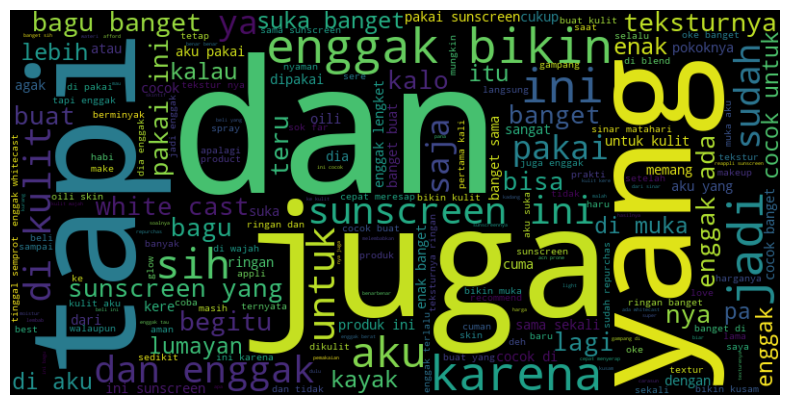

KeyError: 'aspect_term'

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

# Preprocessing Function
def preprocess_text(text):
    # Lowercase text
    text = text.lower()
    
    # Remove numbers and punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    
    # Stemming
    ps = PorterStemmer()
    text = ' '.join([ps.stem(word) for word in text.split()])
    
    return text

# Load the dataset
df = pd.read_csv("C:/Uner/Semester 5/Data Mining II/Coolyeah/TM8/responsi_data.csv", sep=";", encoding="utf-8")


# Cek kolom dataset
print(df.columns)

# Preprocess the text column (assuming the text is in 'review' and 'aspect_term' as the target variable)
df['processed_text'] = df['review'].apply(preprocess_text)

# Visualize data (Word Cloud, Distribution of Labels)
from wordcloud import WordCloud
all_words = ' '.join(df['processed_text'])
wordcloud = WordCloud(width=800, height=400).generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Term Weighting - TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['processed_text'])

# Label encoding for 'aspect_term' (pastikan kolom target ada di dataset)
le = LabelEncoder()
y = le.fit_transform(df['aspect_term'])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define Classification Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier()
}

# Train models and evaluate
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)
    
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': class_report,
        'confusion_matrix': confusion
    }

# Print evaluation results for each model
for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Classification Report:\n{result['classification_report']}")
    print(f"Confusion Matrix:\n{result['confusion_matrix']}")
    print("-" * 50)

# Visualize confusion matrix for the best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = models[best_model_name]
best_confusion_matrix = results[best_model_name]['confusion_matrix']

sns.heatmap(best_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix for {best_model_name}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Final Report for Best Model
print(f"Best Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']}")


In [8]:
import pandas as pd

# Load the dataset
df = pd.read_csv("C:/Uner/Semester 5/Data Mining II/Coolyeah/TM8/responsi_data.csv", sep=";", encoding="utf-8")

# Cek nama-nama kolom dalam dataset
print(df.columns)

# Cek beberapa baris pertama untuk memastikan strukturnya
print(df.head())


Index(['id', 'kode_produk', 'review', 'aspect_term_sentiment'], dtype='object')
                         id  kode_produk  \
0  665c7e0a528efa52655054b3       101646   
1  6619efc643e0623f85cb6ae7        98204   
2  66644ab34658891e039ee5f2       101646   
3  676ee9bc3a193c2c6ef45f3a       101646   
4  67528577576d796c08b4080e        98204   

                                              review  \
0  akhirnya lengkap mulai lengkap variant ini.. j...   
1  kalo untuk sunscreen spray i only trust skinti...   
2  sunscreen terbagus a!! ngl ini benaran se ligh...   
3  produk krim perawatan wajah ini memberikan pen...   
4  cepat habis padahal sudah beli yang gede, tapi...   

                               aspect_term_sentiment  
0    "[{'term': 'tekstur', 'polarity': 'positive'}]"  
1    "[{'term': 'lainnya', 'polarity': 'positive'}]"  
2  "[{'term': 'tekstur', 'polarity': 'positive'},...  
3    "[{'term': 'tekstur', 'polarity': 'positive'}]"  
4       "[{'term': 'aroma', 'polarity': 'ne

Index(['id', 'kode_produk', 'review', 'aspect_term_sentiment'], dtype='object')
Error parsing: "[{'term': 'tekstur', 'polarity': 'negative'},], unterminated string literal (detected at line 1) (<unknown>, line 1)
                               aspect_term_sentiment  term sentiment
0    "[{'term': 'tekstur', 'polarity': 'positive'}]"  None      None
1    "[{'term': 'lainnya', 'polarity': 'positive'}]"  None      None
2  "[{'term': 'tekstur', 'polarity': 'positive'},...  None      None
3    "[{'term': 'tekstur', 'polarity': 'positive'}]"  None      None
4       "[{'term': 'aroma', 'polarity': 'neutral'}]"  None      None


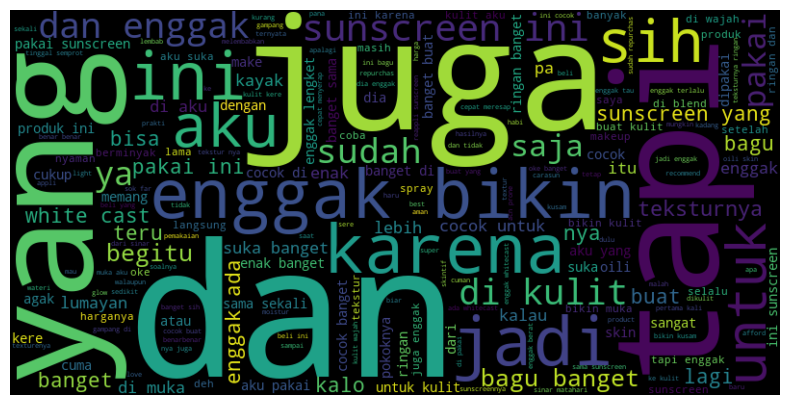

Distribusi Label Term:
term
efek minyak    1
Name: count, dtype: int64
Distribusi Label Sentiment:
sentiment
negative    1
Name: count, dtype: int64


ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 6, n_samples_fit = 1, n_samples = 1

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import ast
from imblearn.over_sampling import SMOTE

# Preprocessing Function
def preprocess_text(text):
    # Lowercase text
    text = text.lower()
    
    # Remove numbers and punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    
    # Stemming
    ps = PorterStemmer()
    text = ' '.join([ps.stem(word) for word in text.split()])
    
    return text

# Load the dataset using semicolon as delimiter
df = pd.read_csv("C:/Uner/Semester 5/Data Mining II/Coolyeah/TM8/responsi_data.csv", sep=";")

# Cek kolom dataset untuk memastikan nama kolom target yang benar
print(df.columns)

# Fungsi untuk ekstrak 'term' dan 'polarity' dari 'aspect_term_sentiment'
def extract_term_sentiment(x):
    try:
        # Mengonversi string JSON menjadi dictionary
        data = ast.literal_eval(x)
        # Ambil 'term' dan 'polarity'
        term = data[0]['term'] if isinstance(data, list) and len(data) > 0 else None
        sentiment = data[0]['polarity'] if isinstance(data, list) and len(data) > 0 else None
        return term, sentiment
    except Exception as e:
        # Jika terjadi error, kembalikan None
        print(f"Error parsing: {x}, {e}")
        return None, None

# Ekstrak 'term' dan 'sentiment' dari 'aspect_term_sentiment'
df[['term', 'sentiment']] = df['aspect_term_sentiment'].apply(lambda x: pd.Series(extract_term_sentiment(x)))

# Cek apakah ekstraksi berhasil
print(df[['aspect_term_sentiment', 'term', 'sentiment']].head())

# Preprocess the text column (assuming the text is in 'review')
df['processed_text'] = df['review'].apply(preprocess_text)

# Visualize data (Word Cloud, Distribution of Labels)
from wordcloud import WordCloud
all_words = ' '.join(df['processed_text'])
wordcloud = WordCloud(width=800, height=400).generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Term Weighting - TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['processed_text'])

# Label encoding for 'term' and 'sentiment'
le_term = LabelEncoder()
le_sentiment = LabelEncoder()

y_term = le_term.fit_transform(df['term'])
y_sentiment = le_sentiment.fit_transform(df['sentiment'])

# Periksa distribusi label untuk memastikan ketidakseimbangan
print("Distribusi Label Term:")
print(df['term'].value_counts())
print("Distribusi Label Sentiment:")
print(df['sentiment'].value_counts())

# Terapkan SMOTE untuk menangani ketidakseimbangan kelas
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Resample data untuk klasifikasi term
X_resampled_term, y_resampled_term = smote.fit_resample(X, y_term)

# Resample data untuk klasifikasi sentiment
X_resampled_sentiment, y_resampled_sentiment = smote.fit_resample(X, y_sentiment)

# Train-Test Split untuk term classification
X_train_term, X_test_term, y_train_term, y_test_term = train_test_split(X_resampled_term, y_resampled_term, test_size=0.3, random_state=42)

# Train-Test Split untuk sentiment classification
X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(X_resampled_sentiment, y_resampled_sentiment, test_size=0.3, random_state=42)

# Define Classification Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier()
}

# Train models and evaluate with cross-validation for both term and sentiment classification
results = {'term': {}, 'sentiment': {}}

# Term Classification Models
for model_name, model in models.items():
    model.fit(X_train_term, y_train_term)
    y_pred_term = model.predict(X_test_term)
    
    accuracy = accuracy_score(y_test_term, y_pred_term)
    class_report = classification_report(y_test_term, y_pred_term)
    confusion = confusion_matrix(y_test_term, y_pred_term)
    
    results['term'][model_name] = {
        'accuracy': accuracy,
        'classification_report': class_report,
        'confusion_matrix': confusion
    }

# Sentiment Classification Models
for model_name, model in models.items():
    model.fit(X_train_sentiment, y_train_sentiment)
    y_pred_sentiment = model.predict(X_test_sentiment)
    
    accuracy = accuracy_score(y_test_sentiment, y_pred_sentiment)
    class_report = classification_report(y_test_sentiment, y_pred_sentiment)
    confusion = confusion_matrix(y_test_sentiment, y_pred_sentiment)
    
    results['sentiment'][model_name] = {
        'accuracy': accuracy,
        'classification_report': class_report,
        'confusion_matrix': confusion
    }

# Print evaluation results for both term and sentiment classification models
for model_name, result in results['term'].items():
    print(f"Model: {model_name} (Term Classification)")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Classification Report:\n{result['classification_report']}")
    print(f"Confusion Matrix:\n{result['confusion_matrix']}")
    print("-" * 50)

for model_name, result in results['sentiment'].items():
    print(f"Model: {model_name} (Sentiment Classification)")
    print(f"Accuracy: {result['accuracy']}")
    print(f"Classification Report:\n{result['classification_report']}")
    print(f"Confusion Matrix:\n{result['confusion_matrix']}")
    print("-" * 50)

# Visualize confusion matrix for the best model (Term Classification)
best_model_name_term = max(results['term'], key=lambda x: results['term'][x]['accuracy'])
best_model_term = models[best_model_name_term]
best_confusion_matrix_term = results['term'][best_model_name_term]['confusion_matrix']

sns.heatmap(best_confusion_matrix_term, annot=True, fmt='d', cmap='Blues', xticklabels=le_term.classes_, yticklabels=le_term.classes_)
plt.title(f"Confusion Matrix for {best_model_name_term} (Term Classification)")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Visualize confusion matrix for the best model (Sentiment Classification)
best_model_name_sentiment = max(results['sentiment'], key=lambda x: results['sentiment'][x]['accuracy'])
best_model_sentiment = models[best_model_name_sentiment]
best_confusion_matrix_sentiment = results['sentiment'][best_model_name_sentiment]['confusion_matrix']

sns.heatmap(best_confusion_matrix_sentiment, annot=True, fmt='d', cmap='Blues', xticklabels=le_sentiment.classes_, yticklabels=le_sentiment.classes_)
plt.title(f"Confusion Matrix for {best_model_name_sentiment} (Sentiment Classification)")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Final Report for Best Model (Term Classification)
print(f"Best Model for Term Classification: {best_model_name_term}")
print(f"Accuracy: {results['term'][best_model_name_term]['accuracy']}")

# Final Report for Best Model (Sentiment Classification)
print(f"Best Model for Sentiment Classification: {best_model_name_sentiment}")
print(f"Accuracy: {results['sentiment'][best_model_name_sentiment]['accuracy']}")


In [3]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_for_absa(filepath):
    """
    Memuat data dan merestrukturisasinya untuk Aspect-Based Sentiment Analysis (ABSA).
    Setiap pasangan term-sentimen menjadi satu baris data terpisah.
    """
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data untuk ABSA...")
    
    # Membaca file dengan delimiter ; dan penanganan error encoding
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            # Mengubah string '""[{...}]""' menjadi list of dicts
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    # Hanya tambahkan data jika term dan polarity ada
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({
                            'review': review_text,
                            'term': aspect['term'],
                            'polarity': aspect['polarity']
                        })
        except (ValueError, SyntaxError, TypeError):
            # Lompati baris yang formatnya aneh atau kosong
            continue
            
    df_restructured = pd.DataFrame(new_data)
    
    # Filter hanya sentimen positif dan negatif
    df_filtered = df_restructured[df_restructured['polarity'].isin(['positive', 'negative'])].copy()

    # Ubah label menjadi angka (0 untuk negatif, 1 untuk positif)
    label_mapping = {'positive': 1, 'negative': 0}
    df_filtered['label'] = df_filtered['polarity'].map(label_mapping)
    df_filtered.dropna(subset=['review', 'term', 'label'], inplace=True)
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin baru: {len(df_filtered)}")
    return df_filtered

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks dan membuat input gabungan untuk BERT."""
    print("\n[Tahap 2] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak', 'ngl': 'sejujurnya', 'omg': 'ya tuhan'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    df['term_cleaned'] = df['term'].apply(clean_text)
    
    # Membuat input gabungan untuk BERT
    df['bert_input'] = df['review_cleaned'] + " [SEP] " + df['term_cleaned']
    
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 3] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    return np.vstack(embeddings)

def train_and_evaluate_models(X, y):
    """Melatih dan mengevaluasi model klasifikasi."""
    print("\n[Tahap 4] Melatih dan Mengevaluasi Model Klasifikasi...")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True)
    }
    
    results = {}
    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
        results[name] = f1
        
    return results

def visualize_results(all_results):
    """Membuat visualisasi perbandingan F1-score semua model."""
    print("\n[Tahap 5] Membuat Visualisasi Hasil Akhir...")
    results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title('Perbandingan F1-Score Model Klasifikasi', fontsize=16); plt.ylabel('F1-Score (Weighted)', fontsize=12); plt.xlabel(''); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.savefig('model_f1_score_comparison.png'); plt.close()
    print("Grafik perbandingan F1-Score disimpan sebagai 'model_f1_score_comparison.png'")

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    
    # Ganti dengan path absolut file Anda jika perlu, atau letakkan di folder yang sama
    file_path = "responsi_data.csv"
    
    try:
        df = restructure_for_absa(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    if len(df) < 20:
        print(f"\n❌ PERINGATAN: Jumlah data poin setelah restrukturisasi ({len(df)}) mungkin terlalu sedikit.")
        if len(df) < 5:
             print("Proses dihentikan karena data kurang dari 5 baris.")
             sys.exit()

    df = preprocess_text(df)

    X_embeddings = get_bert_embeddings(df['bert_input'].tolist())
    y = df['label'].values
    
    final_results = train_and_evaluate_models(X_embeddings, y)

    visualize_results(final_results)

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data untuk ABSA...
Data berhasil direstrukturisasi. Jumlah data poin baru: 2658

[Tahap 2] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...

[Tahap 4] Melatih dan Mengevaluasi Model Klasifikasi...

--- Melatih Logistic Regression ---
F1-Score: 0.8758
              precision    recall  f1-score   support

    Negative       0.50      0.32      0.39        60
    Positive       0.92      0.96      0.94       472

    accuracy                           0.89       532
   macro avg       0.71      0.64      0.66       532
weighted avg       0.87      0.89      0.88       532


--- Melatih Random Forest ---
F1-Score: 0.8387
              precision    recall  f1-score   support

    Negative       1.00      0.02      0.03        60
    Positive       0.89      1.00      0.94       472

    accuracy                           0.89       532
   macro av

In [4]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_for_absa(filepath):
    """
    Memuat data dan merestrukturisasinya untuk Aspect-Based Sentiment Analysis (ABSA).
    """
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data untuk ABSA...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_filtered = df_restructured[df_restructured['polarity'].isin(['positive', 'negative'])].copy()
    label_mapping = {'positive': 1, 'negative': 0}
    df_filtered['label'] = df_filtered['polarity'].map(label_mapping)
    df_filtered.dropna(subset=['review', 'term', 'label'], inplace=True)
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin baru: {len(df_filtered)}")
    return df_filtered

def visualize_eda(df):
    """Membuat visualisasi EDA yang komprehensif."""
    print("\n[Tahap 2] Membuat Visualisasi Exploratory Data Analysis (EDA)...")
    sns.set_style("whitegrid")
    
    # 1. Distribusi Sentimen
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x='polarity', data=df, palette=['#2ecc71', '#e74c3c'], order=['positive', 'negative'])
    plt.title('Distribusi Sentimen Ulasan', fontsize=16); plt.xlabel('Sentimen'); plt.ylabel('Jumlah')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.savefig('1_sentiment_distribution.png'); plt.close()
    print("-> Visualisasi '1_sentiment_distribution.png' disimpan.")

    # 2. Top 15 Aspect Terms
    plt.figure(figsize=(12, 8))
    top_terms = df['term'].value_counts().nlargest(15)
    ax = sns.barplot(x=top_terms.values, y=top_terms.index, palette='viridis', orient='h')
    plt.title('Top 15 Aspect Terms yang Paling Sering Muncul', fontsize=16); plt.xlabel('Jumlah'); plt.ylabel('Aspect Term')
    plt.tight_layout()
    plt.savefig('2_top_aspect_terms.png'); plt.close()
    print("-> Visualisasi '2_top_aspect_terms.png' disimpan.")

    # 3. Distribusi Panjang Ulasan (dalam jumlah kata)
    df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(10, 6))
    sns.histplot(df['review_length'], bins=30, kde=True, color='blue')
    plt.title('Distribusi Panjang Ulasan (Jumlah Kata)', fontsize=16); plt.xlabel('Jumlah Kata'); plt.ylabel('Frekuensi')
    plt.savefig('3_review_length_distribution.png'); plt.close()
    print("-> Visualisasi '3_review_length_distribution.png' disimpan.")

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks dan membuat input gabungan untuk BERT."""
    print("\n[Tahap 3] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    df['term_cleaned'] = df['term'].apply(clean_text)
    df['bert_input'] = df['review_cleaned'] + " [SEP] " + df['term_cleaned']
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 4] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    return np.vstack(embeddings)

def train_and_evaluate_models(X, y):
    """Melatih, mengevaluasi, dan mengidentifikasi model terbaik."""
    print("\n[Tahap 5] Melatih dan Mengevaluasi Model Klasifikasi...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True)
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred}

    return results, best_model_info

def visualize_results(all_results, best_model_info):
    """Membuat visualisasi perbandingan F1-score dan confusion matrix model terbaik."""
    print("\n[Tahap 6] Membuat Visualisasi Hasil Evaluasi...")
    
    # 1. Perbandingan F1-Score
    results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title('Perbandingan F1-Score Model Klasifikasi', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.savefig('4_model_f1_score_comparison.png'); plt.close()
    print("-> Visualisasi '4_model_f1_score_comparison.png' disimpan.")

    # 2. Confusion Matrix untuk Model Terbaik
    best_name = best_model_info['name']
    y_test = best_model_info['y_test']
    y_pred = best_model_info['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'], annot_kws={"size": 14})
    plt.title(f'Confusion Matrix - {best_name}', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.savefig('5_best_model_confusion_matrix.png'); plt.close()
    print(f"-> Confusion matrix untuk model terbaik ({best_name}) disimpan sebagai '5_best_model_confusion_matrix.png'.")

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df = restructure_for_absa(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    if len(df) < 20:
        print(f"\n⚠️ PERINGATAN: Jumlah data ({len(df)}) mungkin terlalu sedikit untuk hasil yang optimal.")
        if len(df) < 5:
             print("❌ ERROR: Proses dihentikan karena data kurang dari 5 baris.")
             sys.exit()

    visualize_eda(df)
    df = preprocess_text(df)
    X_embeddings = get_bert_embeddings(df['bert_input'].tolist())
    y = df['label'].values
    
    final_results, best_model_info = train_and_evaluate_models(X_embeddings, y)
    visualize_results(final_results, best_model_info)

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data untuk ABSA...
Data berhasil direstrukturisasi. Jumlah data poin baru: 2658

[Tahap 2] Membuat Visualisasi Exploratory Data Analysis (EDA)...
-> Visualisasi '1_sentiment_distribution.png' disimpan.
-> Visualisasi '2_top_aspect_terms.png' disimpan.
-> Visualisasi '3_review_length_distribution.png' disimpan.

[Tahap 3] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

[Tahap 4] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...

[Tahap 5] Melatih dan Mengevaluasi Model Klasifikasi...

--- Melatih Logistic Regression ---
F1-Score: 0.8758
              precision    recall  f1-score   support

    Negative       0.50      0.32      0.39        60
    Positive       0.92      0.96      0.94       472

    accuracy                           0.89       532
   macro avg       0.71      0.64      0.66       532
weighted avg       0.87      0.89      0.88       532


--- Melatih Random Forest ---
F1-Score: 0.83

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data untuk ABSA...
Data berhasil direstrukturisasi. Jumlah data poin baru: 2658

[Tahap 2] Menampilkan Visualisasi Exploratory Data Analysis (EDA)...


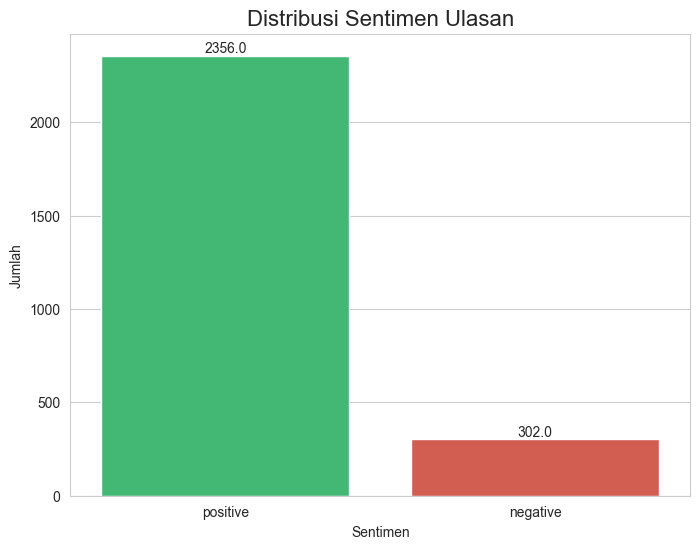

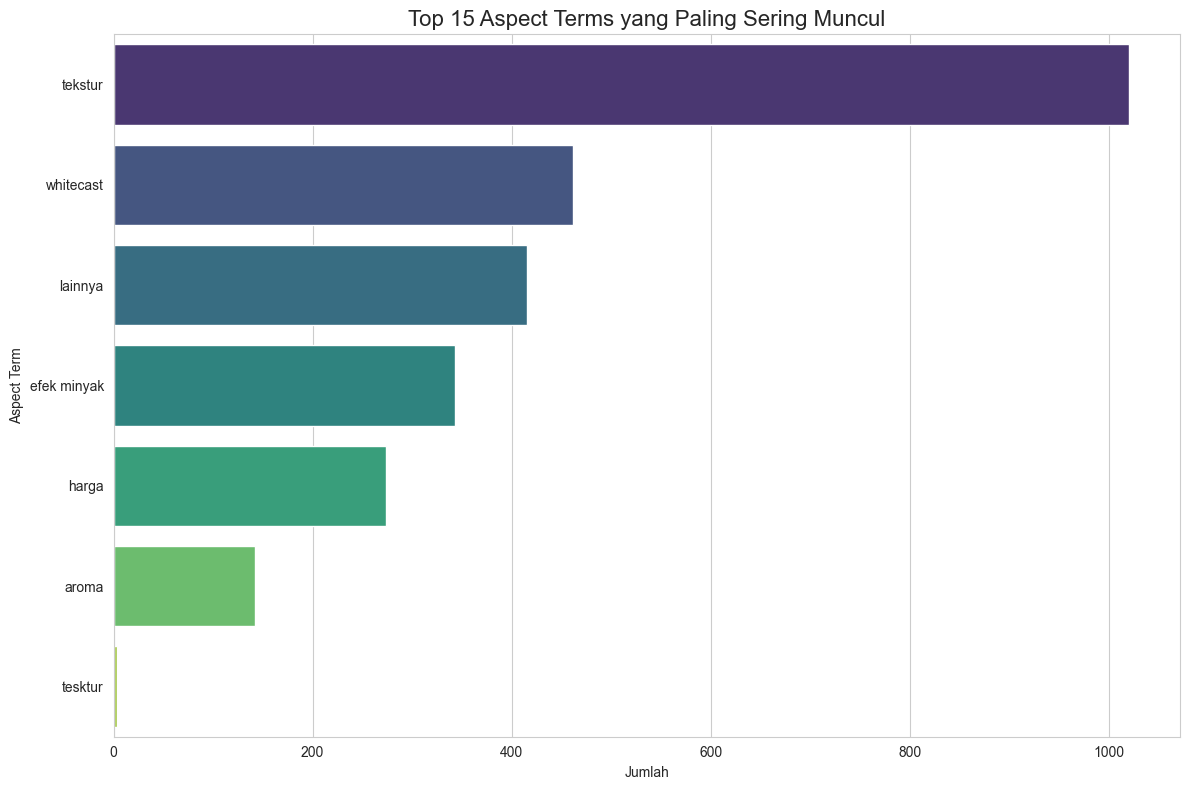

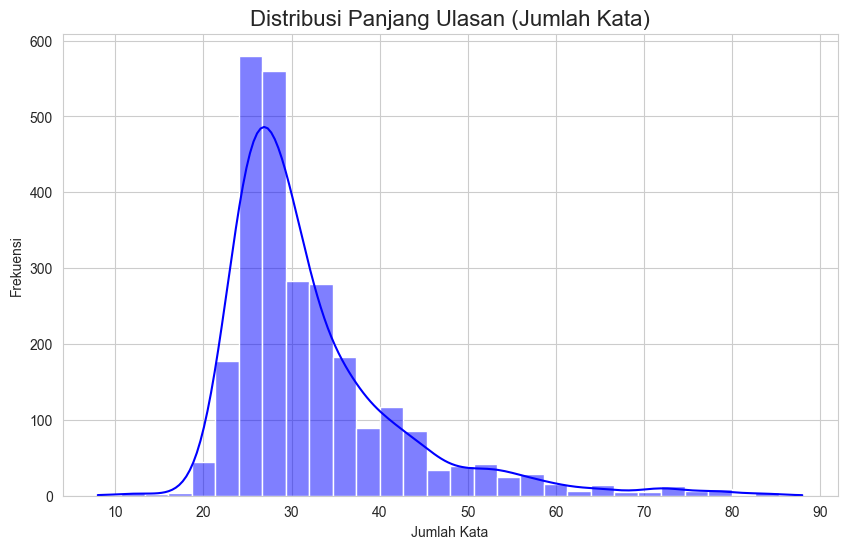


[Tahap 3] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

[Tahap 4] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...

[Tahap 5] Melatih dan Mengevaluasi Model Klasifikasi...

--- Melatih Logistic Regression ---
F1-Score: 0.8758
              precision    recall  f1-score   support

    Negative       0.50      0.32      0.39        60
    Positive       0.92      0.96      0.94       472

    accuracy                           0.89       532
   macro avg       0.71      0.64      0.66       532
weighted avg       0.87      0.89      0.88       532


--- Melatih Random Forest ---
F1-Score: 0.8387
              precision    recall  f1-score   support

    Negative       1.00      0.02      0.03        60
    Positive       0.89      1.00      0.94       472

    accuracy                           0.89       532
   macro avg       0.94      0.51      0.49       532
weighted avg       0.90      0.89      0.84       532


--- Melatih Gaussian Naive Bayes ---
F1-Score

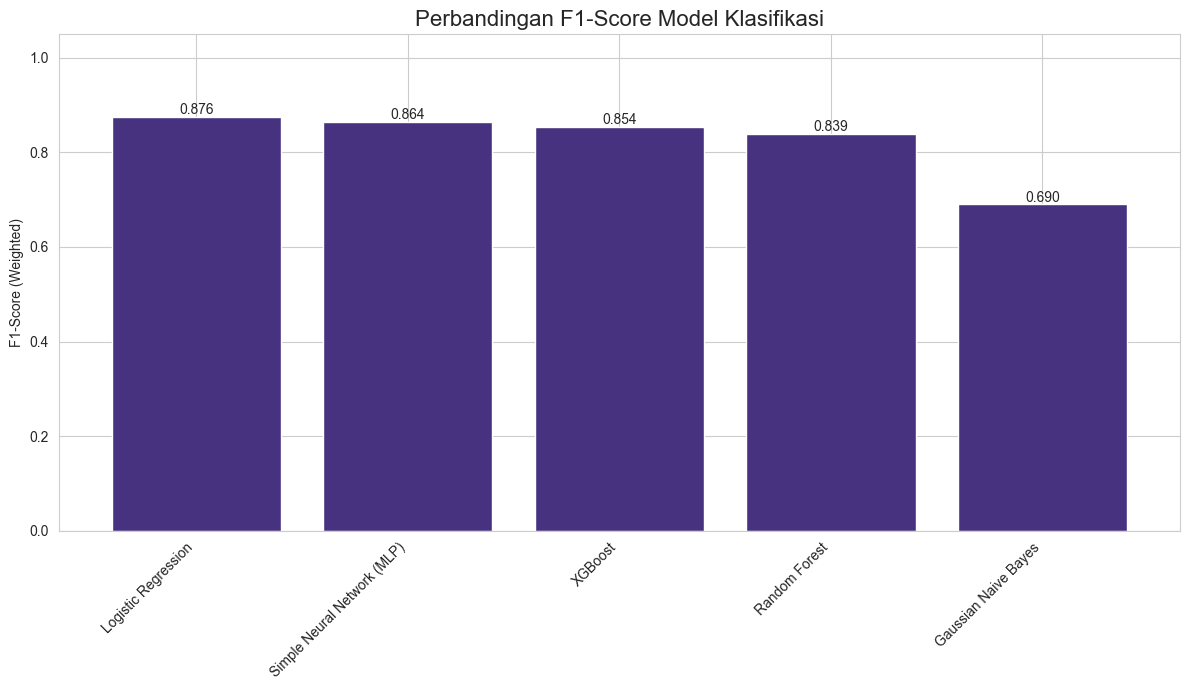

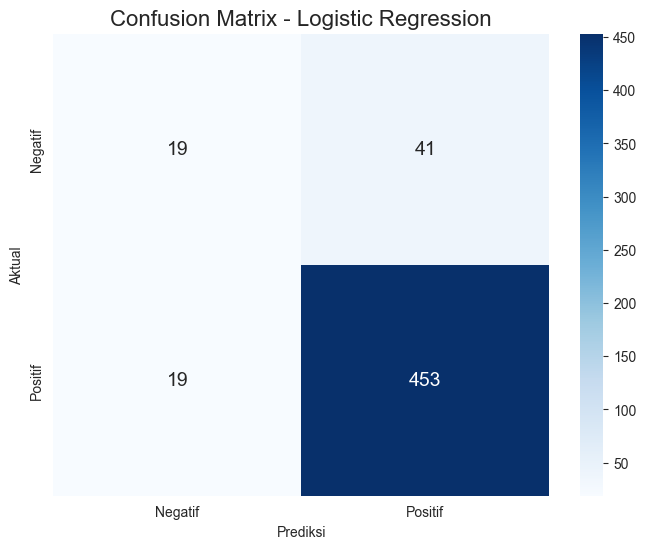


--- ✅ Semua Proses Selesai ---


In [5]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_for_absa(filepath):
    """
    Memuat data dan merestrukturisasinya untuk Aspect-Based Sentiment Analysis (ABSA).
    """
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data untuk ABSA...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_filtered = df_restructured[df_restructured['polarity'].isin(['positive', 'negative'])].copy()
    label_mapping = {'positive': 1, 'negative': 0}
    df_filtered['label'] = df_filtered['polarity'].map(label_mapping)
    df_filtered.dropna(subset=['review', 'term', 'label'], inplace=True)
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin baru: {len(df_filtered)}")
    return df_filtered

def visualize_eda(df):
    """Membuat visualisasi EDA yang komprehensif."""
    print("\n[Tahap 2] Menampilkan Visualisasi Exploratory Data Analysis (EDA)...")
    sns.set_style("whitegrid")
    
    # 1. Distribusi Sentimen
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x='polarity', data=df, palette=['#2ecc71', '#e74c3c'], order=['positive', 'negative'])
    plt.title('Distribusi Sentimen Ulasan', fontsize=16); plt.xlabel('Sentimen'); plt.ylabel('Jumlah')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.show()

    # 2. Top 15 Aspect Terms
    plt.figure(figsize=(12, 8))
    top_terms = df['term'].value_counts().nlargest(15)
    ax = sns.barplot(x=top_terms.values, y=top_terms.index, palette='viridis', orient='h')
    plt.title('Top 15 Aspect Terms yang Paling Sering Muncul', fontsize=16); plt.xlabel('Jumlah'); plt.ylabel('Aspect Term')
    plt.tight_layout()
    plt.show()

    # 3. Distribusi Panjang Ulasan (dalam jumlah kata)
    df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(10, 6))
    sns.histplot(df['review_length'], bins=30, kde=True, color='blue')
    plt.title('Distribusi Panjang Ulasan (Jumlah Kata)', fontsize=16); plt.xlabel('Jumlah Kata'); plt.ylabel('Frekuensi')
    plt.show()

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks dan membuat input gabungan untuk BERT."""
    print("\n[Tahap 3] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    df['term_cleaned'] = df['term'].apply(clean_text)
    df['bert_input'] = df['review_cleaned'] + " [SEP] " + df['term_cleaned']
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 4] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    return np.vstack(embeddings)

def train_and_evaluate_models(X, y):
    """Melatih, mengevaluasi, dan mengidentifikasi model terbaik."""
    print("\n[Tahap 5] Melatih dan Mengevaluasi Model Klasifikasi...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred}

    return results, best_model_info

def visualize_results(all_results, best_model_info):
    """Membuat visualisasi perbandingan F1-score dan confusion matrix model terbaik."""
    print("\n[Tahap 6] Menampilkan Visualisasi Hasil Evaluasi...")
    
    # 1. Perbandingan F1-Score
    results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title('Perbandingan F1-Score Model Klasifikasi', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout()
    plt.show()

    # 2. Confusion Matrix untuk Model Terbaik
    best_name = best_model_info['name']
    y_test = best_model_info['y_test']
    y_pred = best_model_info['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'], annot_kws={"size": 14})
    plt.title(f'Confusion Matrix - {best_name}', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.show()

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df = restructure_for_absa(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    if len(df) < 20:
        print(f"\n⚠️ PERINGATAN: Jumlah data ({len(df)}) mungkin terlalu sedikit untuk hasil yang optimal.")
        if len(df) < 5:
             print("❌ ERROR: Proses dihentikan karena data kurang dari 5 baris.")
             sys.exit()

    visualize_eda(df)
    df = preprocess_text(df)
    X_embeddings = get_bert_embeddings(df['bert_input'].tolist())
    y = df['label'].values
    
    final_results, best_model_info = train_and_evaluate_models(X_embeddings, y)
    visualize_results(final_results, best_model_info)

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data untuk Klasifikasi Term...
Data berhasil direstrukturisasi. Jumlah data poin baru: 2776

[Tahap 2] Menampilkan Visualisasi EDA untuk Term...


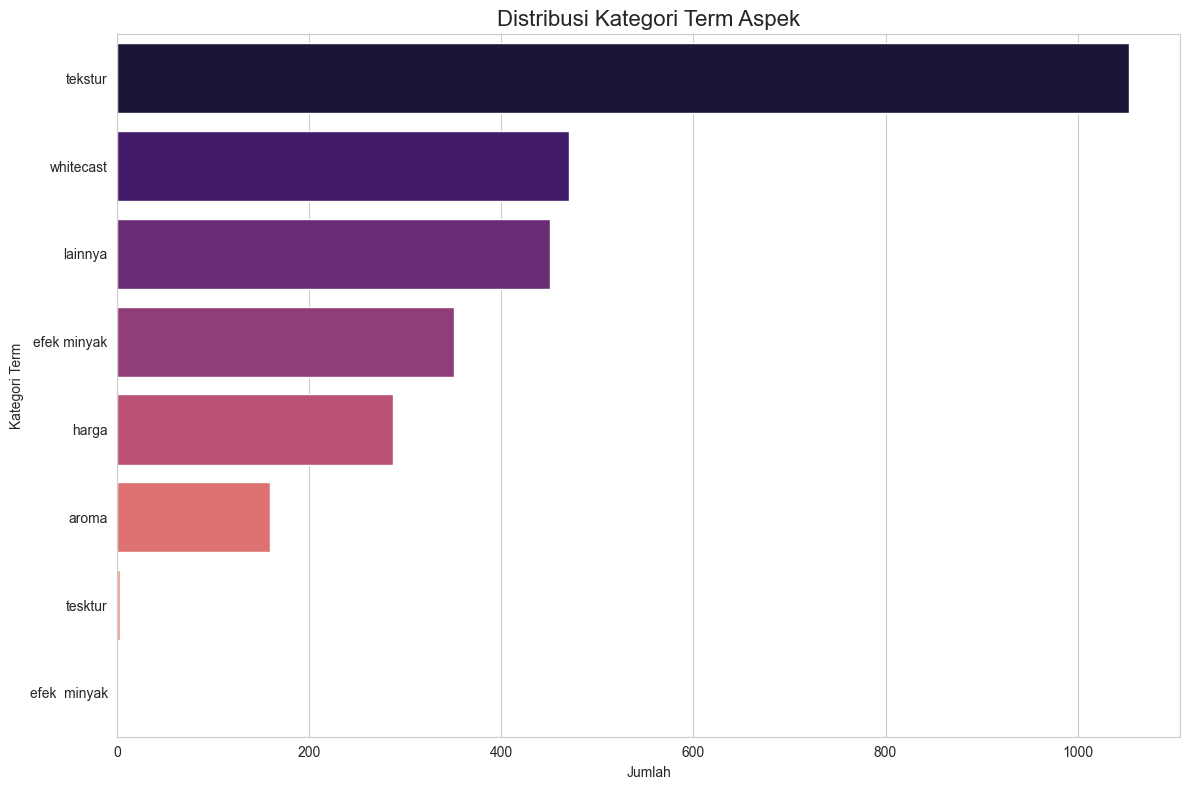


[Tahap 3] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

Kategori Term yang akan diklasifikasi: ['aroma' 'efek  minyak' 'efek minyak' 'harga' 'lainnya' 'tekstur'
 'tesktur' 'whitecast']

[Tahap 4] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...

[Tahap 5] Melatih dan Mengevaluasi Model Klasifikasi Multi-class...


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [6]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_for_multiclass_term(filepath):
    """
    Memuat data dan merestrukturisasinya untuk klasifikasi term multi-class.
    """
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data untuk Klasifikasi Term...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        # Kita ambil semua term, termasuk yang sentimennya neutral
                        new_data.append({'review': review_text, 'term': aspect['term']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_restructured.dropna(subset=['review', 'term'], inplace=True)
    df_restructured = df_restructured[df_restructured['term'].str.strip() != '']

    # Menggabungkan term yang mirip jika perlu (opsional, bisa disesuaikan)
    # Contoh: df_restructured['term'] = df_restructured['term'].replace({'harga produk': 'harga'})

    print(f"Data berhasil direstrukturisasi. Jumlah data poin baru: {len(df_restructured)}")
    return df_restructured

def visualize_eda_multiclass(df):
    """Membuat visualisasi EDA untuk klasifikasi multi-class."""
    print("\n[Tahap 2] Menampilkan Visualisasi EDA untuk Term...")
    sns.set_style("whitegrid")
    
    # 1. Distribusi Kategori Term
    plt.figure(figsize=(12, 8))
    ax = sns.countplot(y='term', data=df, order=df['term'].value_counts().index, palette='magma')
    plt.title('Distribusi Kategori Term Aspek', fontsize=16)
    plt.xlabel('Jumlah'); plt.ylabel('Kategori Term')
    plt.tight_layout()
    plt.show()

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks pada kolom review."""
    print("\n[Tahap 3] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 4] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    return np.vstack(embeddings)

def train_and_evaluate_models(X, y, labels):
    """Melatih, mengevaluasi, dan mengidentifikasi model terbaik."""
    print("\n[Tahap 5] Melatih dan Mengevaluasi Model Klasifikasi Multi-class...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr'),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, target_names=labels))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred, 'labels': labels}

    return results, best_model_info

def visualize_results(all_results, best_model_info):
    """Membuat visualisasi perbandingan F1-score dan confusion matrix model terbaik."""
    print("\n[Tahap 6] Menampilkan Visualisasi Hasil Evaluasi...")
    
    # 1. Perbandingan F1-Score
    results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title('Perbandingan F1-Score Model Klasifikasi', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout()
    plt.show()

    # 2. Confusion Matrix untuk Model Terbaik
    best_name = best_model_info['name']
    y_test = best_model_info['y_test']
    y_pred = best_model_info['y_pred']
    labels = best_model_info['labels']
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {best_name}', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df = restructure_for_multiclass_term(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    if len(df) < 20:
        print(f"\n⚠️ PERINGATAN: Jumlah data ({len(df)}) mungkin terlalu sedikit.")
        if len(df) < 5:
             print("❌ ERROR: Proses dihentikan karena data kurang dari 5 baris.")
             sys.exit()

    visualize_eda_multiclass(df)
    
    df = preprocess_text(df)
    
    # Mengubah label term menjadi numerik
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(df['term'])
    class_labels = label_encoder.classes_
    
    print(f"\nKategori Term yang akan diklasifikasi: {class_labels}")
    
    X_embeddings = get_bert_embeddings(df['review_cleaned'].tolist())
    
    final_results, best_model_info = train_and_evaluate_models(X_embeddings, y_encoded, class_labels)
    visualize_results(final_results, best_model_info)

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data...
Data berhasil direstrukturisasi. Jumlah data poin: 2776

[Tahap 2] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||

Kelas Sentimen: ['negative' 'neutral' 'positive' 'positve' 'postive']


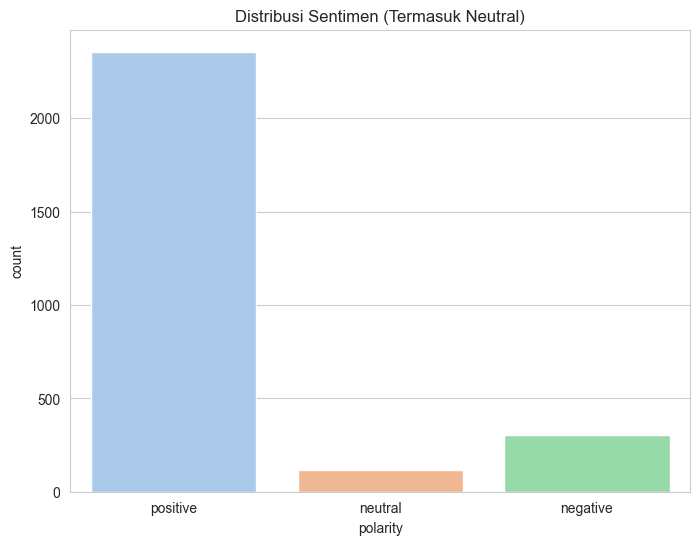


[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Sentimen ---


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [7]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_data(filepath):
    """Memuat dan merestrukturisasi data. Setiap pasangan term-sentimen menjadi baris terpisah."""
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_restructured.dropna(subset=['review', 'term', 'polarity'], inplace=True)
    df_restructured = df_restructured[df_restructured['term'].str.strip() != '']
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin: {len(df_restructured)}")
    return df_restructured

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks pada kolom review."""
    print("\n[Tahap 2] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 3] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        print(f"  - Memproses batch {i//batch_size + 1}/{(len(texts)//batch_size)+1}", end='\r')
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    print("\nEkstraksi embedding selesai.")
    return np.vstack(embeddings)

def train_and_evaluate(X, y, labels, task_name=""):
    """Fungsi generik untuk melatih, mengevaluasi, dan memvisualisasikan hasil."""
    print(f"\n--- Memulai Pelatihan untuk Tugas: {task_name} ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss' if len(labels)>2 else 'logloss')
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, target_names=labels))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred, 'labels': labels}
    
    # Visualisasi Hasil
    print(f"\n--- Menampilkan Visualisasi Hasil untuk Tugas: {task_name} ---")
    results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title(f'Perbandingan F1-Score Model ({task_name})', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()

    best_name = best_model_info['name']
    cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'])
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {best_name} ({task_name})', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout(); plt.show()


# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df_base = restructure_data(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    if len(df_base) < 20:
        print(f"\n⚠️ PERINGATAN: Jumlah data ({len(df_base)}) mungkin terlalu sedikit.")
        if len(df_base) < 5:
             print("❌ ERROR: Proses dihentikan karena data kurang dari 5 baris.")
             sys.exit()

    df_processed = preprocess_text(df_base.copy())

    # --- TUGAS 1: KLASIFIKASI SENTIMEN (POSITIVE, NEGATIVE, NEUTRAL) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||")
    print("="*50)
    df_sentiment = df_processed.copy()
    df_sentiment['term_cleaned'] = df_sentiment['term'].apply(lambda x: ' '.join(str(x).lower().split()))
    df_sentiment['bert_input'] = df_sentiment['review_cleaned'] + " [SEP] " + df_sentiment['term_cleaned']
    
    le_sentiment = LabelEncoder()
    y_sentiment = le_sentiment.fit_transform(df_sentiment['polarity'])
    sentiment_labels = le_sentiment.classes_
    print(f"\nKelas Sentimen: {sentiment_labels}")

    plt.figure(figsize=(8, 6)); sns.countplot(x='polarity', data=df_sentiment, order=['positive', 'neutral', 'negative'], palette='pastel')
    plt.title('Distribusi Sentimen (Termasuk Neutral)'); plt.show()
    
    X_sentiment = get_bert_embeddings(df_sentiment['bert_input'].tolist())
    train_and_evaluate(X_sentiment, y_sentiment, sentiment_labels, task_name="Klasifikasi Sentimen")

    # --- TUGAS 2: KLASIFIKASI TERM (TEKSTUR, AROMA, DLL.) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||")
    print("="*50)
    df_term = df_processed.copy()

    le_term = LabelEncoder()
    y_term = le_term.fit_transform(df_term['term'])
    term_labels = le_term.classes_
    print(f"\nKelas Term: {term_labels}")

    plt.figure(figsize=(12, 8)); sns.countplot(y='term', data=df_term, order=df_term['term'].value_counts().index, palette='magma')
    plt.title('Distribusi Kategori Term Aspek'); plt.tight_layout(); plt.show()

    X_term = get_bert_embeddings(df_term['review_cleaned'].tolist())
    train_and_evaluate(X_term, y_term, term_labels, task_name="Klasifikasi Term Aspek")

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data...
Data berhasil direstrukturisasi. Jumlah data poin awal: 2776

[Tahap 2] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||

[Filter] Menemukan 1 kelas langka (kurang dari 2 sampel) di kolom 'polarity'.
Kelas yang dihapus: ['postive']
Jumlah data setelah filter: 2775

Kelas Sentimen: ['negative' 'neutral' 'positive' 'positve']


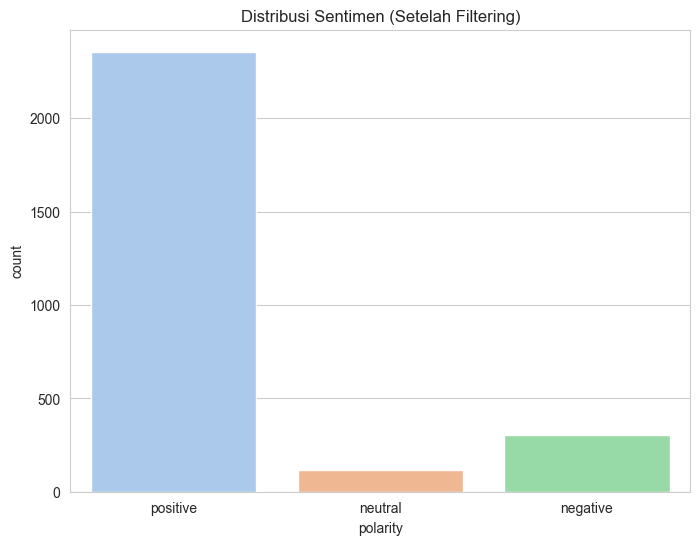


[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Sentimen ---

--- Melatih Logistic Regression ---
F1-Score: 0.8123


ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter

In [8]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_data(filepath):
    """Memuat dan merestrukturisasi data. Setiap pasangan term-sentimen menjadi baris terpisah."""
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_restructured.dropna(subset=['review', 'term', 'polarity'], inplace=True)
    df_restructured = df_restructured[df_restructured['term'].str.strip() != '']
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin awal: {len(df_restructured)}")
    return df_restructured

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks pada kolom review."""
    print("\n[Tahap 2] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 3] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        print(f"  - Memproses batch {i//batch_size + 1}/{(len(texts)//batch_size)+1}", end='\r')
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    print("\nEkstraksi embedding selesai.")
    return np.vstack(embeddings)

def train_and_evaluate(X, y, labels, task_name=""):
    """Fungsi generik untuk melatih, mengevaluasi, dan memvisualisasikan hasil."""
    print(f"\n--- Memulai Pelatihan untuk Tugas: {task_name} ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss' if len(labels)>2 else 'logloss')
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, target_names=labels, zero_division=0))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred, 'labels': labels}
    
    # Visualisasi Hasil
    print(f"\n--- Menampilkan Visualisasi Hasil untuk Tugas: {task_name} ---")
    results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title(f'Perbandingan F1-Score Model ({task_name})', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()

    best_name = best_model_info['name']
    cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'])
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {best_name} ({task_name})', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout(); plt.show()

def filter_rare_classes(df, column_name):
    """Menghapus baris dari kelas yang memiliki kurang dari 2 anggota."""
    class_counts = df[column_name].value_counts()
    rare_classes = class_counts[class_counts < 2].index.tolist()
    
    if rare_classes:
        print(f"\n[Filter] Menemukan {len(rare_classes)} kelas langka (kurang dari 2 sampel) di kolom '{column_name}'.")
        print(f"Kelas yang dihapus: {rare_classes}")
        df_filtered = df[~df[column_name].isin(rare_classes)]
        print(f"Jumlah data setelah filter: {len(df_filtered)}")
        return df_filtered
    else:
        print(f"\n[Filter] Tidak ada kelas langka di kolom '{column_name}'. Tidak ada data yang dihapus.")
        return df

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df_base = restructure_data(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    df_processed = preprocess_text(df_base.copy())

    # --- TUGAS 1: KLASIFIKASI SENTIMEN (POSITIVE, NEGATIVE, NEUTRAL) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||")
    print("="*50)
    df_sentiment = filter_rare_classes(df_processed.copy(), 'polarity')
    df_sentiment['term_cleaned'] = df_sentiment['term'].apply(lambda x: ' '.join(str(x).lower().split()))
    df_sentiment['bert_input'] = df_sentiment['review_cleaned'] + " [SEP] " + df_sentiment['term_cleaned']
    
    le_sentiment = LabelEncoder()
    y_sentiment = le_sentiment.fit_transform(df_sentiment['polarity'])
    sentiment_labels = le_sentiment.classes_
    print(f"\nKelas Sentimen: {sentiment_labels}")

    plt.figure(figsize=(8, 6)); sns.countplot(x='polarity', data=df_sentiment, order=['positive', 'neutral', 'negative'], palette='pastel')
    plt.title('Distribusi Sentimen (Setelah Filtering)'); plt.show()
    
    X_sentiment = get_bert_embeddings(df_sentiment['bert_input'].tolist())
    train_and_evaluate(X_sentiment, y_sentiment, sentiment_labels, task_name="Klasifikasi Sentimen")

    # --- TUGAS 2: KLASIFIKASI TERM (TEKSTUR, AROMA, DLL.) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||")
    print("="*50)
    df_term = filter_rare_classes(df_processed.copy(), 'term')

    le_term = LabelEncoder()
    y_term = le_term.fit_transform(df_term['term'])
    term_labels = le_term.classes_
    print(f"\nKelas Term (Setelah Filtering): {term_labels}")

    plt.figure(figsize=(12, 8)); sns.countplot(y='term', data=df_term, order=df_term['term'].value_counts().index, palette='magma')
    plt.title('Distribusi Kategori Term Aspek (Setelah Filtering)'); plt.tight_layout(); plt.show()

    X_term = get_bert_embeddings(df_term['review_cleaned'].tolist())
    train_and_evaluate(X_term, y_term, term_labels, task_name="Klasifikasi Term Aspek")

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data...
Data berhasil direstrukturisasi. Jumlah data poin awal: 2776

[Tahap 2] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||

[Filter] Menemukan 1 kelas langka (kurang dari 2 sampel) di kolom 'polarity'.
Kelas yang dihapus: ['postive']
Jumlah data setelah filter: 2775

Kelas Sentimen: ['negative' 'neutral' 'positive' 'positve']


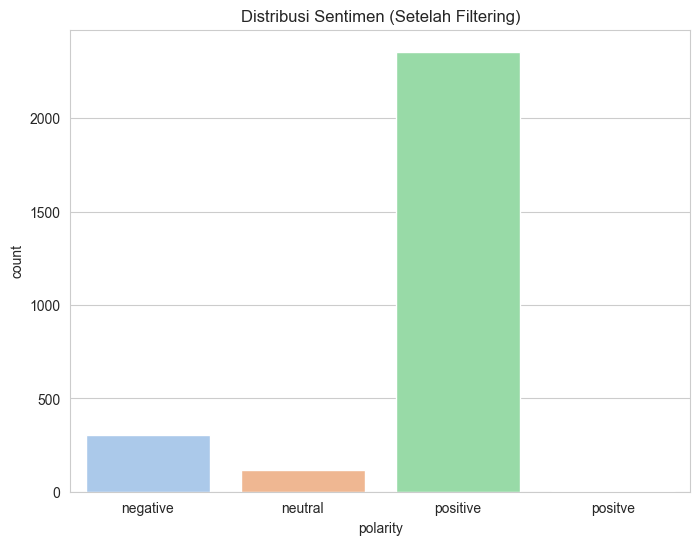


[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Sentimen ---

--- Melatih Logistic Regression ---
F1-Score: 0.8123
              precision    recall  f1-score   support

    negative       0.42      0.34      0.38        61
     neutral       0.08      0.04      0.06        23
    positive       0.89      0.93      0.91       471
     positve       0.00      0.00      0.00         0

    accuracy                           0.83       555
   macro avg       0.35      0.33      0.33       555
weighted avg       0.80      0.83      0.81       555


--- Melatih Random Forest ---
F1-Score: 0.7877
              precision    recall  f1-score   support

    negative       1.00      0.03      0.06        61
     neutral       0.00      0.00      0.00        23
    positive       0.85      1.00      0.92       471
     positve       0.00      0.00      0.00       

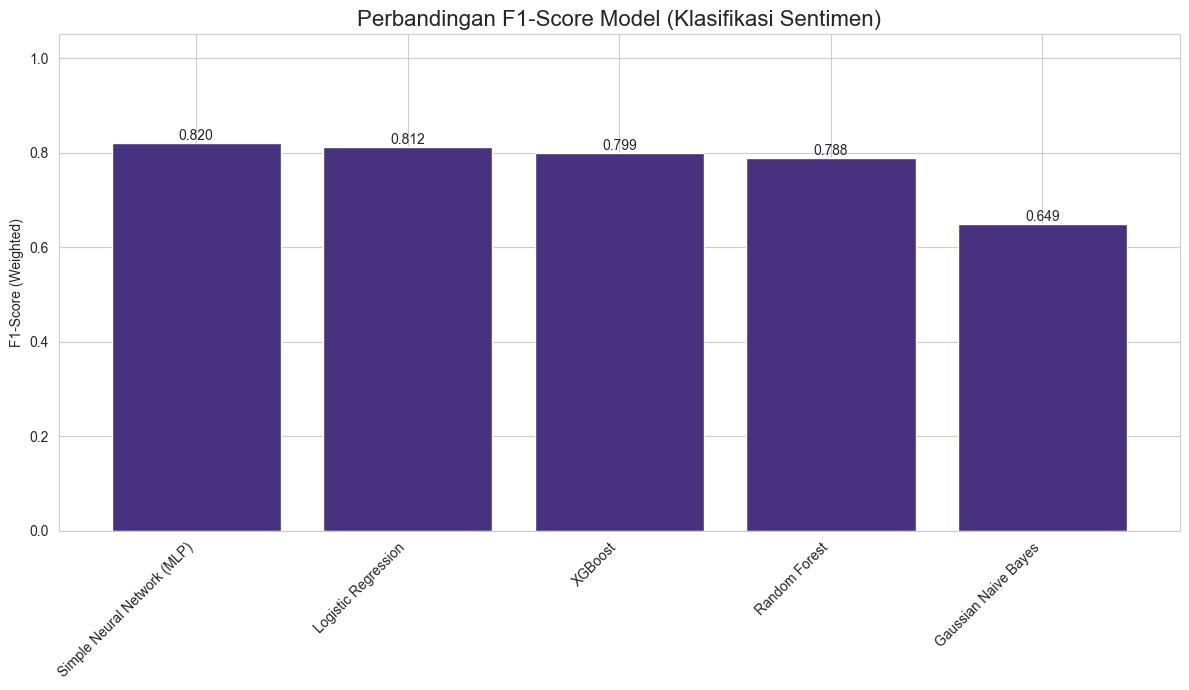

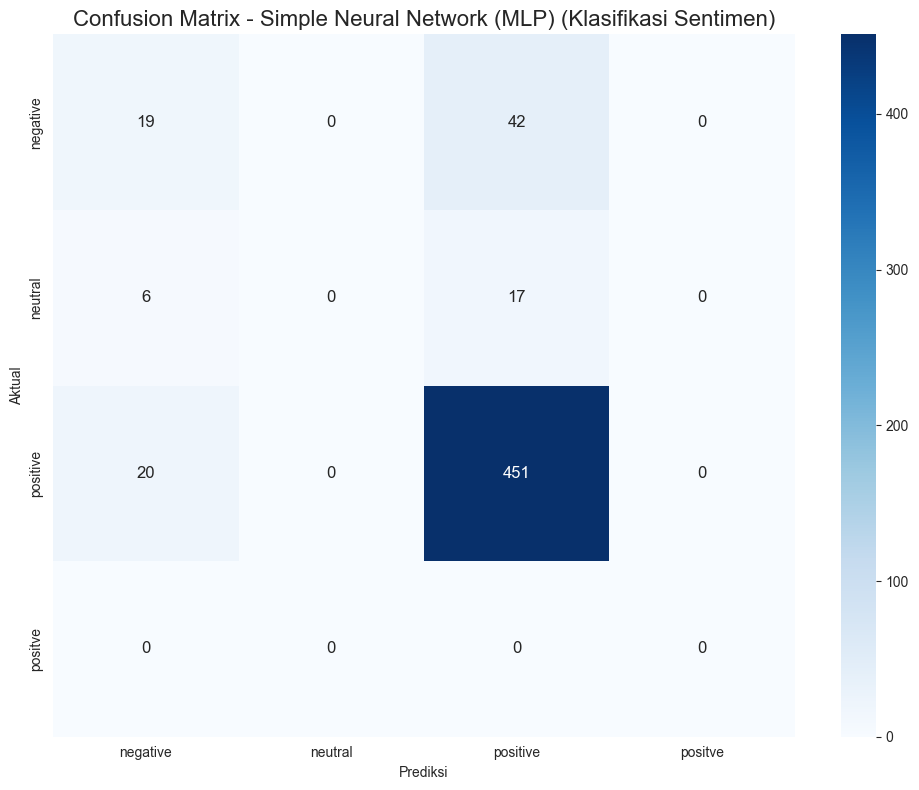


|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||

[Filter] Menemukan 1 kelas langka (kurang dari 2 sampel) di kolom 'term'.
Kelas yang dihapus: ['efek  minyak']
Jumlah data setelah filter: 2775

Kelas Term (Setelah Filtering): ['aroma' 'efek minyak' 'harga' 'lainnya' 'tekstur' 'tesktur' 'whitecast']


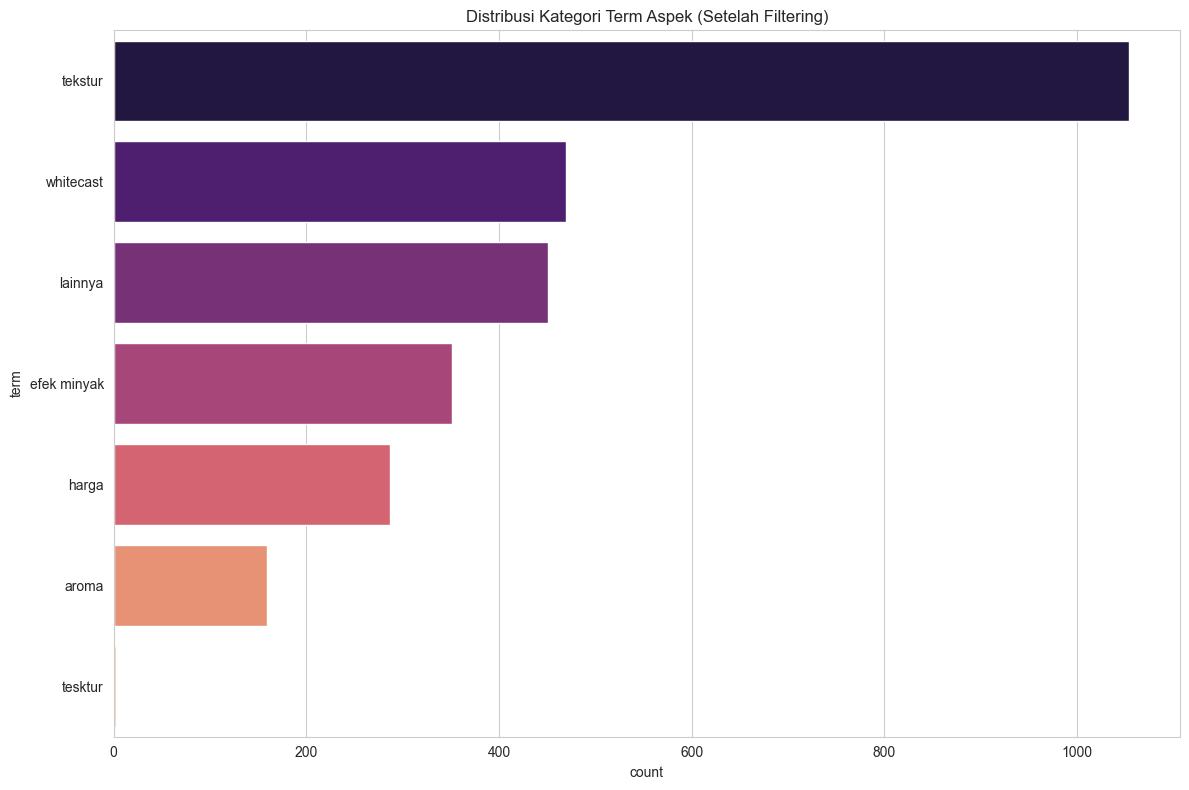


[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Term Aspek ---

--- Melatih Logistic Regression ---
F1-Score: 0.3539
              precision    recall  f1-score   support

       aroma       0.18      0.16      0.17        32
 efek minyak       0.17      0.16      0.16        70
       harga       0.21      0.19      0.20        57
     lainnya       0.74      0.71      0.73        90
     tekstur       0.39      0.41      0.40       211
     tesktur       0.00      0.00      0.00         1
   whitecast       0.19      0.20      0.20        94

    accuracy                           0.35       555
   macro avg       0.27      0.26      0.26       555
weighted avg       0.35      0.35      0.35       555


--- Melatih Random Forest ---
F1-Score: 0.2383
              precision    recall  f1-score   support

       aroma       0.00      0.00      0.00     

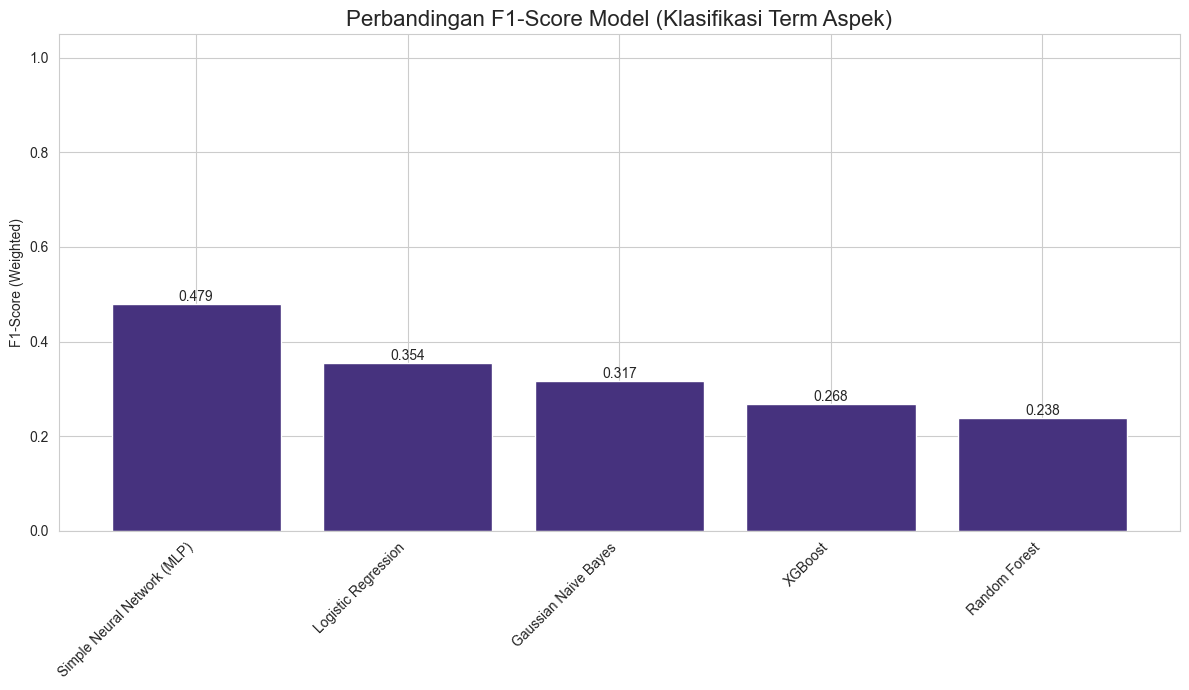

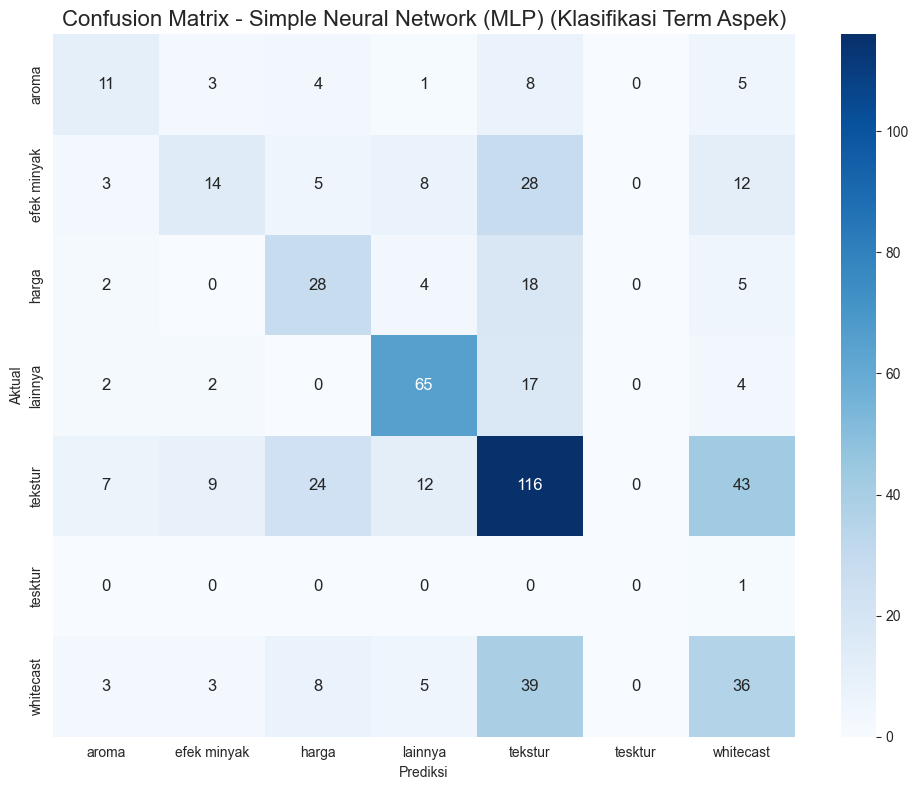


--- ✅ Semua Proses Selesai ---


In [9]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_data(filepath):
    """Memuat dan merestrukturisasi data. Setiap pasangan term-sentimen menjadi baris terpisah."""
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_restructured.dropna(subset=['review', 'term', 'polarity'], inplace=True)
    df_restructured = df_restructured[df_restructured['term'].str.strip() != '']
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin awal: {len(df_restructured)}")
    return df_restructured

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks pada kolom review."""
    print("\n[Tahap 2] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 3] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        print(f"  - Memproses batch {i//batch_size + 1}/{(len(texts)//batch_size)+1}", end='\r')
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    print("\nEkstraksi embedding selesai.")
    return np.vstack(embeddings)

def train_and_evaluate(X, y, le, task_name=""):
    """Fungsi generik untuk melatih, mengevaluasi, dan memvisualisasikan hasil."""
    print(f"\n--- Memulai Pelatihan untuk Tugas: {task_name} ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    string_labels = le.classes_
    numerical_labels = le.transform(string_labels)

    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss' if len(string_labels)>2 else 'logloss')
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        
        # PERBAIKAN: Gunakan parameter 'labels' untuk menangani kelas yang hilang di test set
        print(classification_report(y_test, y_pred, labels=numerical_labels, target_names=string_labels, zero_division=0))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred, 'labels': string_labels}
    
    # Visualisasi Hasil
    print(f"\n--- Menampilkan Visualisasi Hasil untuk Tugas: {task_name} ---")
    results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title(f'Perbandingan F1-Score Model ({task_name})', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()

    best_name = best_model_info['name']
    cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'], labels=le.transform(best_model_info['labels']))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=string_labels, yticklabels=string_labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {best_name} ({task_name})', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout(); plt.show()

def filter_rare_classes(df, column_name):
    """Menghapus baris dari kelas yang memiliki kurang dari 2 anggota."""
    class_counts = df[column_name].value_counts()
    rare_classes = class_counts[class_counts < 2].index.tolist()
    
    if rare_classes:
        print(f"\n[Filter] Menemukan {len(rare_classes)} kelas langka (kurang dari 2 sampel) di kolom '{column_name}'.")
        print(f"Kelas yang dihapus: {rare_classes}")
        df_filtered = df[~df[column_name].isin(rare_classes)]
        print(f"Jumlah data setelah filter: {len(df_filtered)}")
        return df_filtered
    else:
        print(f"\n[Filter] Tidak ada kelas langka di kolom '{column_name}'. Tidak ada data yang dihapus.")
        return df

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df_base = restructure_data(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    df_processed = preprocess_text(df_base.copy())

    # --- TUGAS 1: KLASIFIKASI SENTIMEN (POSITIVE, NEGATIVE, NEUTRAL) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||")
    print("="*50)
    df_sentiment = filter_rare_classes(df_processed.copy(), 'polarity')
    df_sentiment['term_cleaned'] = df_sentiment['term'].apply(lambda x: ' '.join(str(x).lower().split()))
    df_sentiment['bert_input'] = df_sentiment['review_cleaned'] + " [SEP] " + df_sentiment['term_cleaned']
    
    le_sentiment = LabelEncoder()
    y_sentiment = le_sentiment.fit_transform(df_sentiment['polarity'])
    
    print(f"\nKelas Sentimen: {le_sentiment.classes_}")

    plt.figure(figsize=(8, 6)); sns.countplot(x='polarity', data=df_sentiment, order=le_sentiment.classes_, palette='pastel')
    plt.title('Distribusi Sentimen (Setelah Filtering)'); plt.show()
    
    X_sentiment = get_bert_embeddings(df_sentiment['bert_input'].tolist())
    train_and_evaluate(X_sentiment, y_sentiment, le_sentiment, task_name="Klasifikasi Sentimen")

    # --- TUGAS 2: KLASIFIKASI TERM (TEKSTUR, AROMA, DLL.) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||")
    print("="*50)
    df_term = filter_rare_classes(df_processed.copy(), 'term')

    le_term = LabelEncoder()
    y_term = le_term.fit_transform(df_term['term'])
    
    print(f"\nKelas Term (Setelah Filtering): {le_term.classes_}")

    plt.figure(figsize=(12, 8)); sns.countplot(y='term', data=df_term, order=df_term['term'].value_counts().index, palette='magma')
    plt.title('Distribusi Kategori Term Aspek (Setelah Filtering)'); plt.tight_layout(); plt.show()

    X_term = get_bert_embeddings(df_term['review_cleaned'].tolist())
    train_and_evaluate(X_term, y_term, le_term, task_name="Klasifikasi Term Aspek")

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data...
Data berhasil direstrukturisasi. Jumlah data poin: 2776

[Tahap 2] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||

Kelas Sentimen: ['negative' 'neutral' 'positive' 'positve' 'postive']


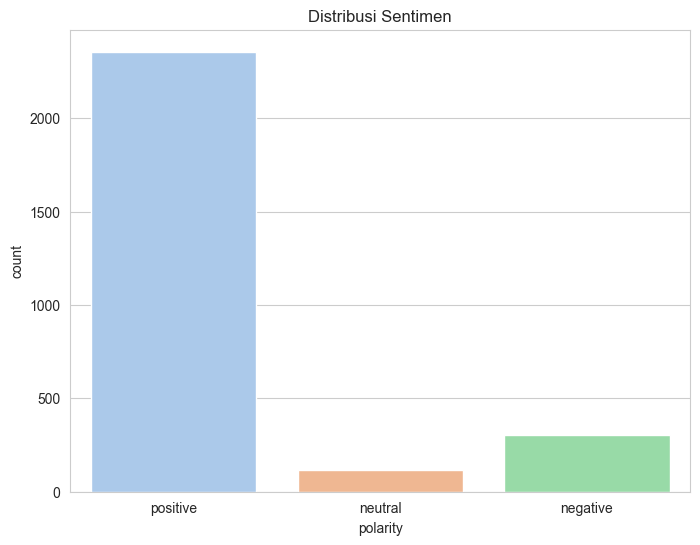


[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Sentimen ---
⚠️ Peringatan: Salah satu kelas memiliki kurang dari 2 sampel. Stratifikasi dinonaktifkan.

--- Melatih Logistic Regression ---
F1-Score: 0.8394
              precision    recall  f1-score   support

    negative       0.43      0.37      0.40        54
     neutral       0.00      0.00      0.00        18
    positive       0.91      0.93      0.92       484
     positve       0.00      0.00      0.00         0
     postive       0.00      0.00      0.00         0

    accuracy                           0.85       556
   macro avg       0.27      0.26      0.26       556
weighted avg       0.83      0.85      0.84       556


--- Melatih Random Forest ---
F1-Score: 0.8273
              precision    recall  f1-score   support

    negative       0.80      0.07      0.14        54
     neutral 

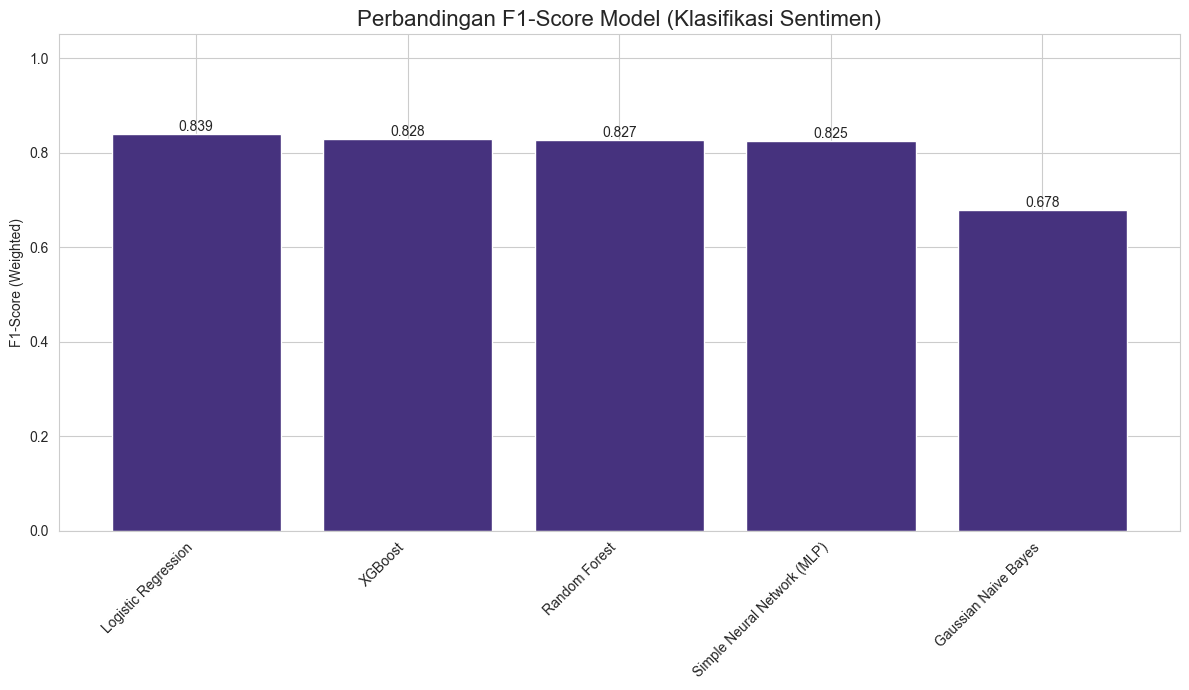

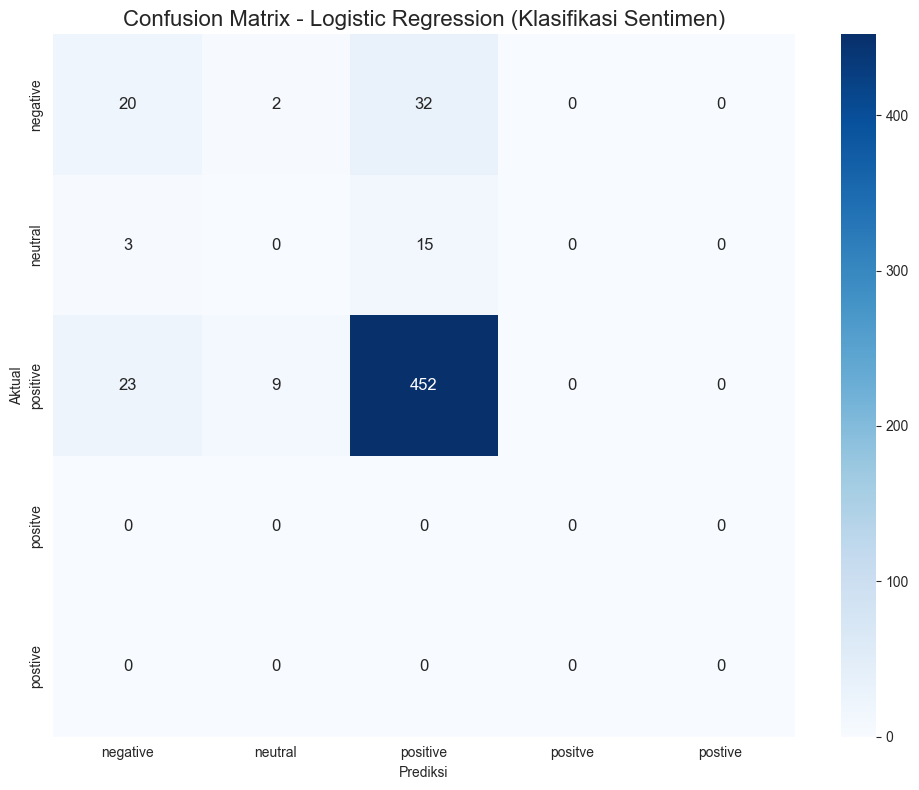


|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||

Kelas Term yang Telah Dipetakan: ['aroma' 'lainnya' 'tekstur']


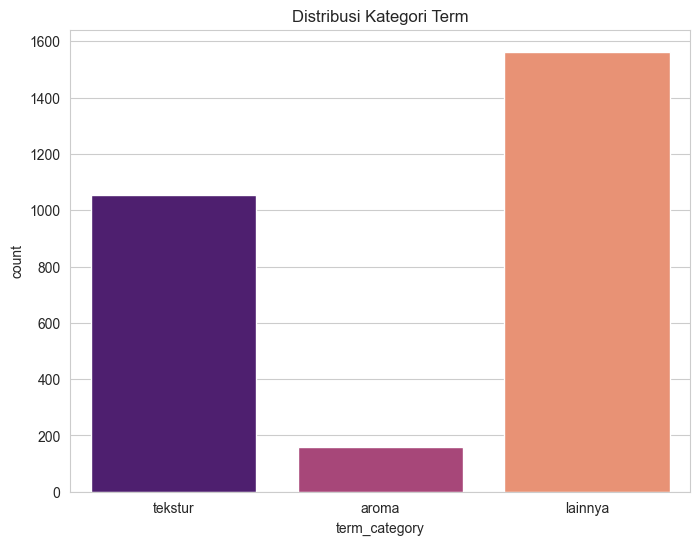


[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Term Aspek ---

--- Melatih Logistic Regression ---
F1-Score: 0.5118
              precision    recall  f1-score   support

       aroma       0.05      0.03      0.04        32
     lainnya       0.61      0.64      0.62       313
     tekstur       0.43      0.42      0.42       211

    accuracy                           0.52       556
   macro avg       0.36      0.36      0.36       556
weighted avg       0.51      0.52      0.51       556


--- Melatih Random Forest ---
F1-Score: 0.3981
              precision    recall  f1-score   support

       aroma       0.00      0.00      0.00        32
     lainnya       0.52      0.65      0.58       313
     tekstur       0.23      0.16      0.19       211

    accuracy                           0.43       556
   macro avg       0.25      0.27      0.26    

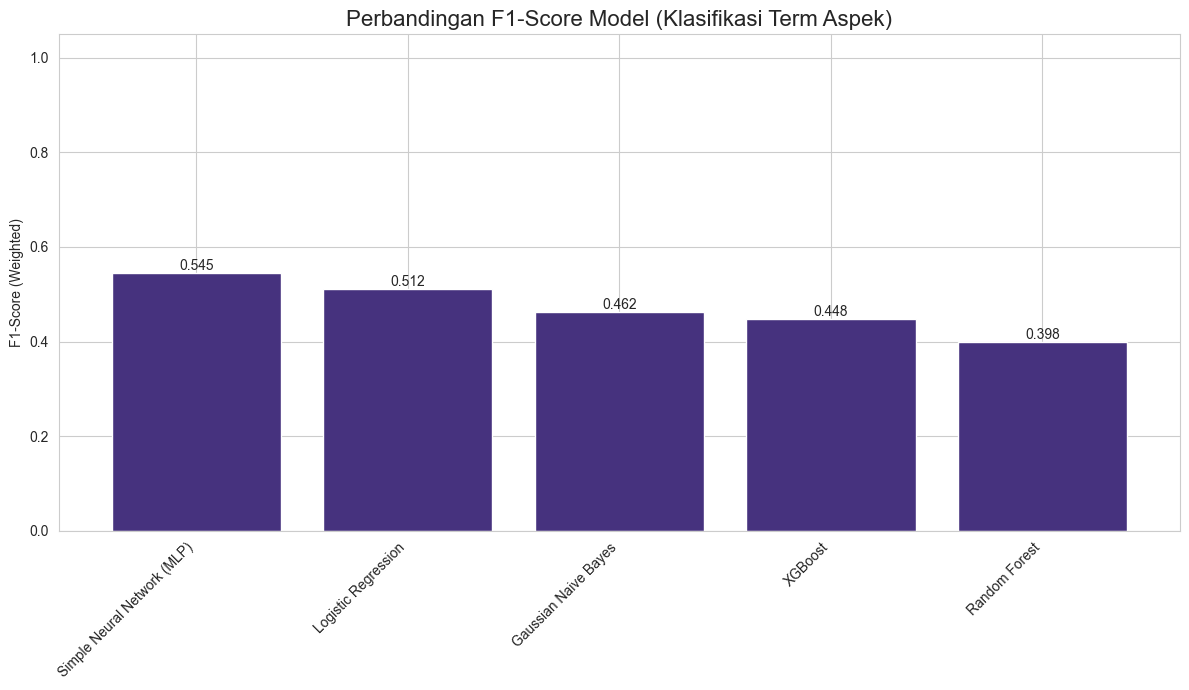

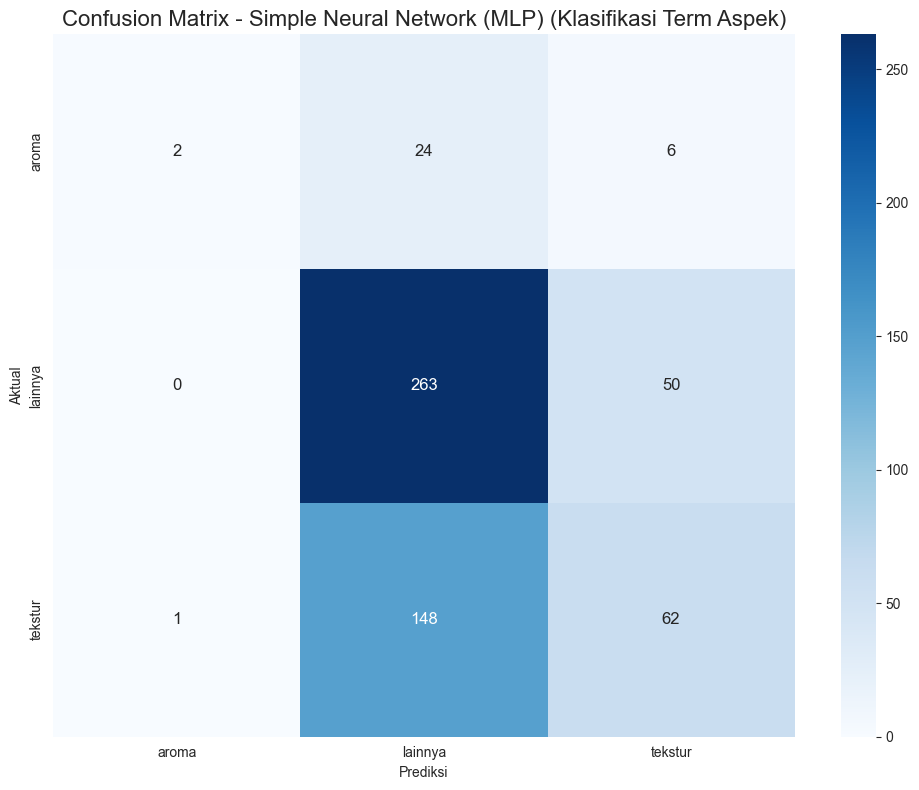


--- ✅ Semua Proses Selesai ---


In [10]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_data(filepath):
    """Memuat dan merestrukturisasi data. Setiap pasangan term-sentimen menjadi baris terpisah."""
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_restructured.dropna(subset=['review', 'term', 'polarity'], inplace=True)
    df_restructured = df_restructured[df_restructured['term'].str.strip() != '']
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin: {len(df_restructured)}")
    return df_restructured

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks pada kolom review."""
    print("\n[Tahap 2] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 3] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        print(f"  - Memproses batch {i//batch_size + 1}/{(len(texts)//batch_size)+1}", end='\r')
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    print("\nEkstraksi embedding selesai.")
    return np.vstack(embeddings)

def train_and_evaluate(X, y, le, task_name=""):
    """Fungsi generik untuk melatih, mengevaluasi, dan memvisualisasikan hasil."""
    print(f"\n--- Memulai Pelatihan untuk Tugas: {task_name} ---")
    
    # Cek stratifikasi
    label_counts = pd.Series(y).value_counts()
    if (label_counts < 2).any():
        print("⚠️ Peringatan: Salah satu kelas memiliki kurang dari 2 sampel. Stratifikasi dinonaktifkan.")
        stratify_option = None
    else:
        stratify_option = y

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=stratify_option)
    
    string_labels = le.classes_
    numerical_labels = le.transform(string_labels)

    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss' if len(string_labels)>2 else 'logloss')
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, labels=numerical_labels, target_names=string_labels, zero_division=0))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred, 'labels': string_labels}
    
    print(f"\n--- Menampilkan Visualisasi Hasil untuk Tugas: {task_name} ---")
    results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title(f'Perbandingan F1-Score Model ({task_name})', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()

    best_name = best_model_info['name']
    cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'], labels=le.transform(best_model_info['labels']))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=string_labels, yticklabels=string_labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {best_name} ({task_name})', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout(); plt.show()

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df_base = restructure_data(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    if len(df_base) < 5:
         print("❌ ERROR: Proses dihentikan karena data kurang dari 5 baris.")
         sys.exit()

    df_processed = preprocess_text(df_base.copy())

    # --- TUGAS 1: KLASIFIKASI SENTIMEN (POSITIVE, NEGATIVE, NEUTRAL) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||")
    print("="*50)
    df_sentiment = df_processed.copy()
    df_sentiment['term_cleaned'] = df_sentiment['term'].apply(lambda x: ' '.join(str(x).lower().split()))
    df_sentiment['bert_input'] = df_sentiment['review_cleaned'] + " [SEP] " + df_sentiment['term_cleaned']
    
    le_sentiment = LabelEncoder()
    y_sentiment = le_sentiment.fit_transform(df_sentiment['polarity'])
    print(f"\nKelas Sentimen: {le_sentiment.classes_}")

    plt.figure(figsize=(8, 6)); sns.countplot(x='polarity', data=df_sentiment, order=['positive', 'neutral', 'negative'], palette='pastel')
    plt.title('Distribusi Sentimen'); plt.show()
    
    X_sentiment = get_bert_embeddings(df_sentiment['bert_input'].tolist())
    train_and_evaluate(X_sentiment, y_sentiment, le_sentiment, task_name="Klasifikasi Sentimen")

    # --- TUGAS 2: KLASIFIKASI TERM (TEKSTUR, AROMA, LAINNYA) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||")
    print("="*50)
    
    # --- PERBAIKAN UTAMA: FUNGSI MAPPING KATEGORI ---
    def map_term_to_category(term):
        term = term.lower()
        if term == 'tekstur':
            return 'tekstur'
        elif term == 'aroma':
            return 'aroma'
        else:
            return 'lainnya'

    df_term = df_processed.copy()
    df_term['term_category'] = df_term['term'].apply(map_term_to_category)

    le_term = LabelEncoder()
    y_term = le_term.fit_transform(df_term['term_category'])
    print(f"\nKelas Term yang Telah Dipetakan: {le_term.classes_}")

    plt.figure(figsize=(8, 6)); sns.countplot(x='term_category', data=df_term, order=['tekstur', 'aroma', 'lainnya'], palette='magma')
    plt.title('Distribusi Kategori Term'); plt.show()

    X_term = get_bert_embeddings(df_term['review_cleaned'].tolist())
    train_and_evaluate(X_term, y_term, le_term, task_name="Klasifikasi Term Aspek")

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data...
Data berhasil direstrukturisasi. Jumlah data poin: 2776

[Tahap 2] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||


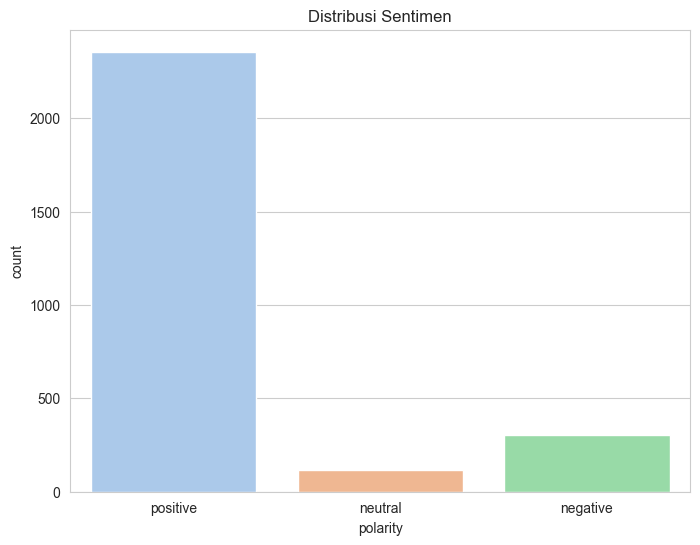

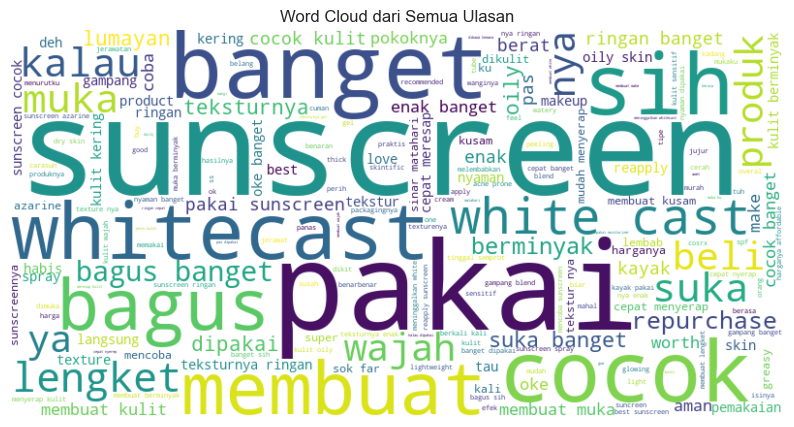


Kelas Sentimen: ['negative' 'neutral' 'positive' 'positve' 'postive']

[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Sentimen ---

--- Melatih Logistic Regression ---
F1-Score: 0.8394
              precision    recall  f1-score   support

    negative       0.43      0.37      0.40        54
     neutral       0.00      0.00      0.00        18
    positive       0.91      0.93      0.92       484
     positve       0.00      0.00      0.00         0
     postive       0.00      0.00      0.00         0

    accuracy                           0.85       556
   macro avg       0.27      0.26      0.26       556
weighted avg       0.83      0.85      0.84       556


--- Melatih Random Forest ---
F1-Score: 0.8273
              precision    recall  f1-score   support

    negative       0.80      0.07      0.14        54
     neutral       0.00      0.00

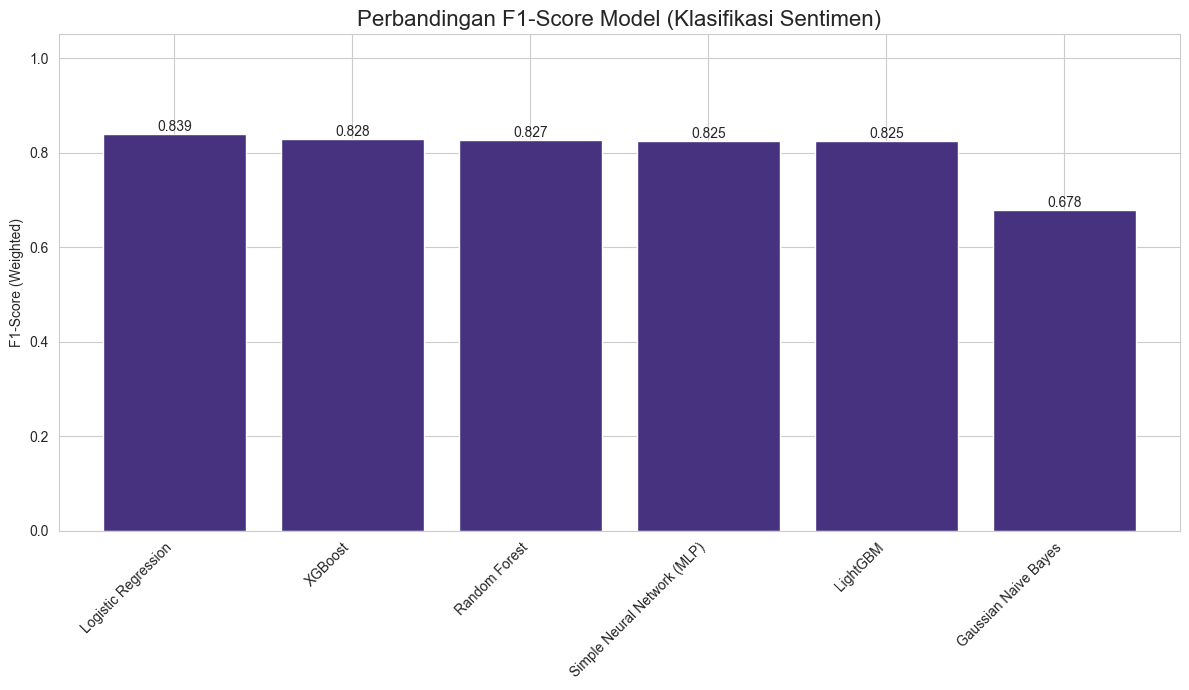

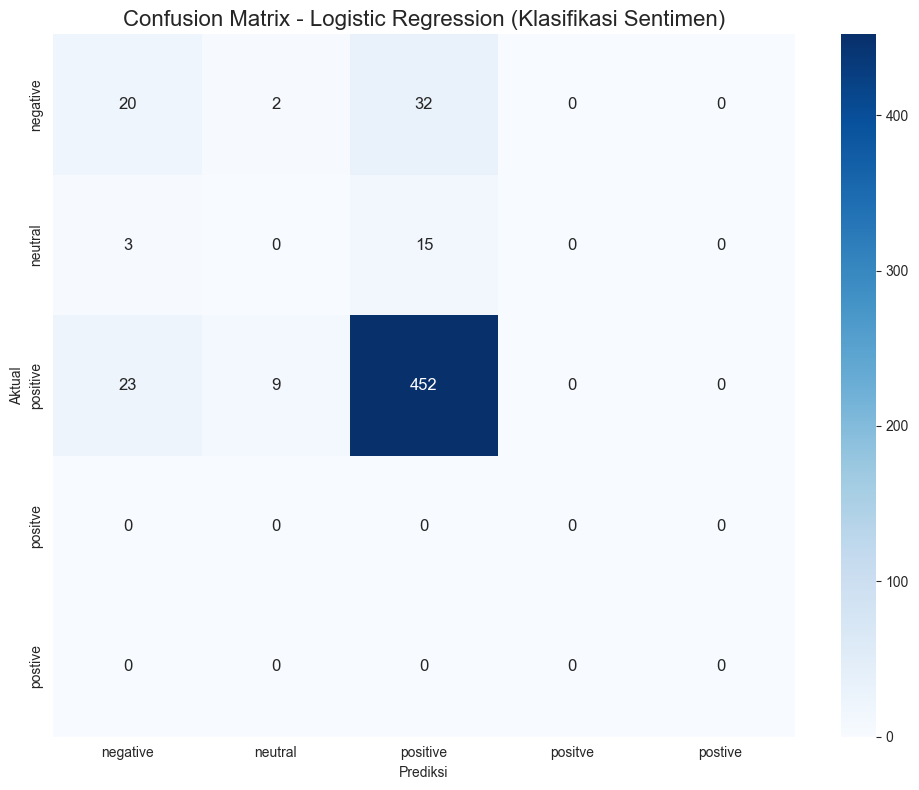


--- Analisis Kesalahan untuk Model Terbaik: Logistic Regression ---
Menampilkan 10 dari 84 kesalahan prediksi:
                                                                                                                                                                                                  Review Asli  \
929   produk sunscreen yang lumayan oke tapi untuk harga menengah lah ya untuk pamakaian cocok di kulit yang sensitiv jadi yang mau coba masih oke saja, tekstur oke banget karena sangat ringan tapi afte...   
834   sunscreen mist yang aku suka karena simple terus efektif di wajah juga enggak bikin make up rusak pakai ini kalau lagi keluar-keluar saja jadi selalu ada di tas dan menurut aku ini awet banget ent...   
2243  buat harga ini termasuk pricey sih ya di kantong pelajar tapi untuk efek tone up dan melembapkan nya ini juaraaabener benar enggak bikin kusam even sudah dipakai panas panasan, if lu guys have muc...   
2060             teruntuk muka yang kering & sensi b

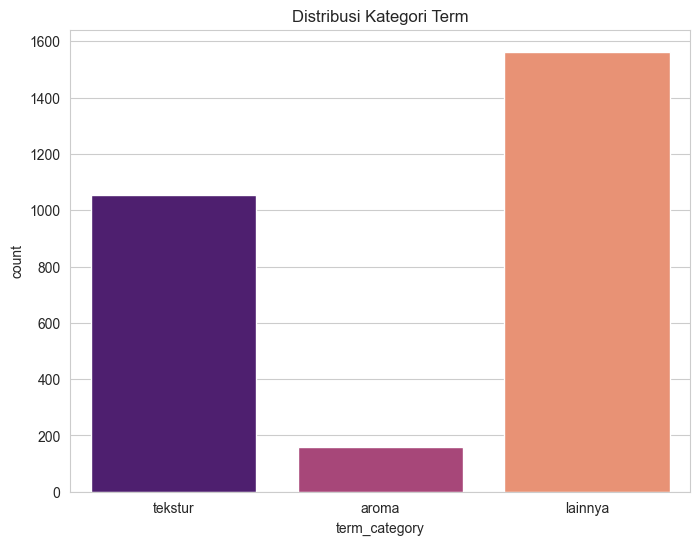


Kelas Term yang Telah Dipetakan: ['aroma' 'lainnya' 'tekstur']

[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Term Aspek ---

--- Melatih Logistic Regression ---
F1-Score: 0.5118
              precision    recall  f1-score   support

       aroma       0.05      0.03      0.04        32
     lainnya       0.61      0.64      0.62       313
     tekstur       0.43      0.42      0.42       211

    accuracy                           0.52       556
   macro avg       0.36      0.36      0.36       556
weighted avg       0.51      0.52      0.51       556


--- Melatih Random Forest ---
F1-Score: 0.3981
              precision    recall  f1-score   support

       aroma       0.00      0.00      0.00        32
     lainnya       0.52      0.65      0.58       313
     tekstur       0.23      0.16      0.19       211

    accuracy                         

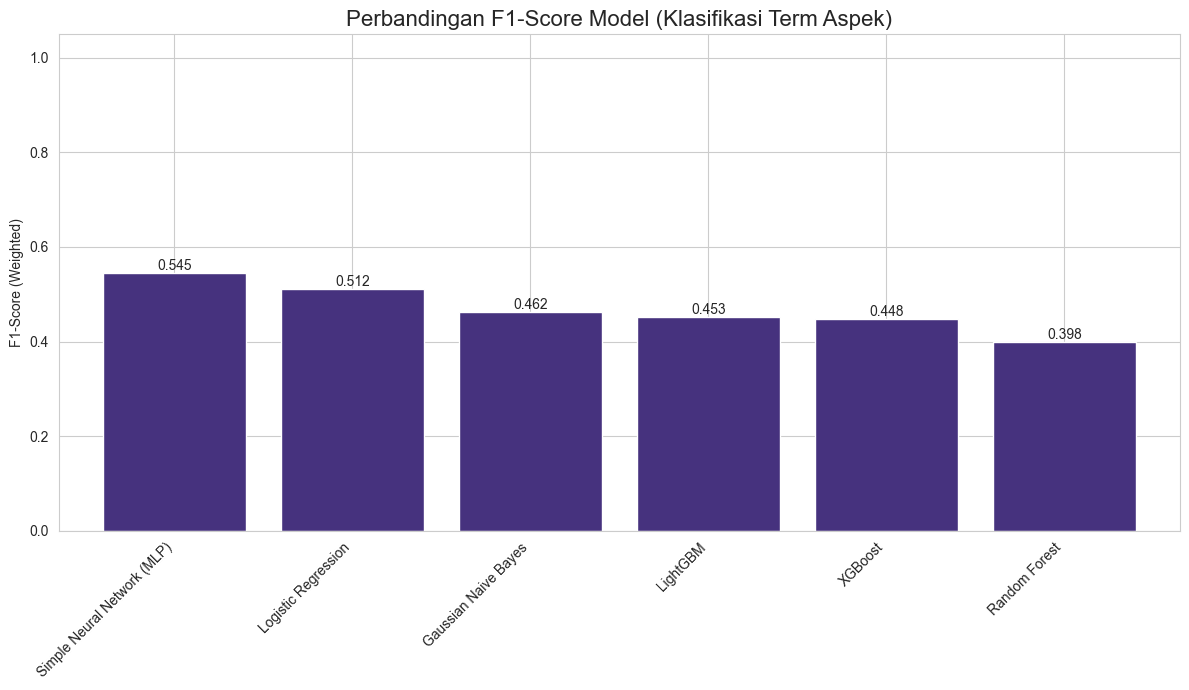

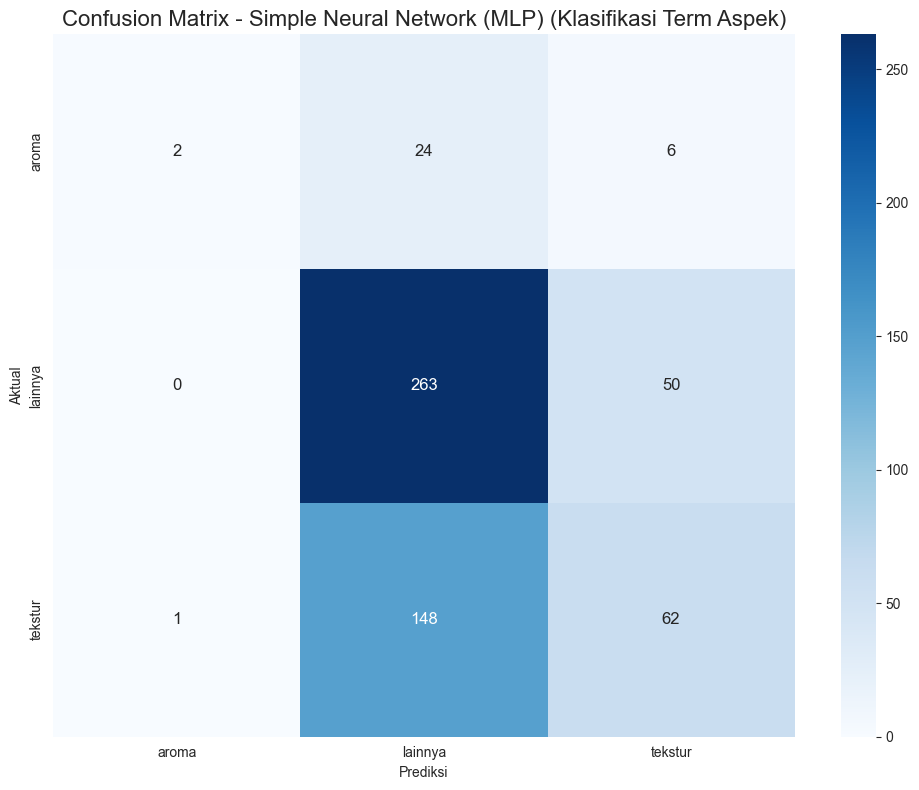


--- Analisis Kesalahan untuk Model Terbaik: Simple Neural Network (MLP) ---
Menampilkan 10 dari 229 kesalahan prediksi:
                                                                                                                                                                                                  Review Asli  \
779   aku rasa pakai carasun ini oke-oke saja sih di muka ku, enggak ada side effect yang macam-macam (kayak breakout dl), cuma memang texturenya agak kentel saja sih, dan kerasanya enggak begitu ringan...   
528                   pertama beli karena reviewnya bagus bagus banget, and this lived up tapi its hype sih. texturenya ringan banget dan itu leaves a glowy finish. worth itu banget for an affordable price   
209                                        suka sama teksturnya gel dan enggak lengket, sudah repurchase berkali kali dan ini botol ke13. bikin muka lebih lembab dan enggak bikin komedoan thankyou azarine!   
233                                   prakt

In [11]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb
import lightgbm as lgb # Import LightGBM

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_data(filepath):
    """Memuat dan merestrukturisasi data."""
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_restructured.dropna(subset=['review', 'term', 'polarity'], inplace=True)
    df_restructured = df_restructured[df_restructured['term'].str.strip() != '']
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin: {len(df_restructured)}")
    return df_restructured

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks pada kolom review."""
    print("\n[Tahap 2] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 3] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        print(f"  - Memproses batch {i//batch_size + 1}/{(len(texts)//batch_size)+1}", end='\r')
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    print("\nEkstraksi embedding selesai.")
    return np.vstack(embeddings)

def train_and_evaluate(X, y, le, original_reviews, task_name=""):
    """Fungsi generik untuk melatih, mengevaluasi, dan menganalisis hasil."""
    print(f"\n--- Memulai Pelatihan untuk Tugas: {task_name} ---")
    
    # Cek stratifikasi
    label_counts = pd.Series(y).value_counts()
    stratify_option = y if not (label_counts < 2).any() else None

    # Pastikan original_reviews juga di-split dengan index yang sama
    indices = np.arange(X.shape[0])
    X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
        X, y, indices, test_size=0.2, random_state=42, stratify=stratify_option
    )
    reviews_test = original_reviews.iloc[indices_test]

    string_labels = le.classes_
    numerical_labels = le.transform(string_labels)

    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss' if len(string_labels)>2 else 'logloss'),
        "LightGBM": lgb.LGBMClassifier(random_state=42) # PENAMBAHAN LIGHTGBM
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, labels=numerical_labels, target_names=string_labels, zero_division=0))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred, 'labels': string_labels, 'reviews': reviews_test}
    
    visualize_and_analyze(results, best_model_info, le, task_name)

def visualize_and_analyze(all_results, best_model_info, le, task_name=""):
    """Menampilkan visualisasi hasil dan analisis kesalahan."""
    print(f"\n--- Menampilkan Visualisasi & Analisis untuk Tugas: {task_name} ---")
    
    # 1. Visualisasi Perbandingan F1-Score
    results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title(f'Perbandingan F1-Score Model ({task_name})', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()

    # 2. Visualisasi Confusion Matrix
    best_name = best_model_info['name']
    string_labels = best_model_info['labels']
    cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'], labels=le.transform(string_labels))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=string_labels, yticklabels=string_labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {best_name} ({task_name})', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout(); plt.show()
    
    # 3. Analisis Kesalahan
    print(f"\n--- Analisis Kesalahan untuk Model Terbaik: {best_name} ---")
    y_test_labels = le.inverse_transform(best_model_info['y_test'])
    y_pred_labels = le.inverse_transform(best_model_info['y_pred'])
    
    error_df = pd.DataFrame({
        'Review Asli': best_model_info['reviews'],
        'Label Sebenarnya': y_test_labels,
        'Label Prediksi': y_pred_labels
    })
    
    errors = error_df[error_df['Label Sebenarnya'] != error_df['Label Prediksi']]
    
    if errors.empty:
        print("🎉 Selamat! Tidak ada kesalahan prediksi pada test set.")
    else:
        pd.set_option('display.max_colwidth', 200)
        print(f"Menampilkan {min(10, len(errors))} dari {len(errors)} kesalahan prediksi:")
        print(errors.head(10))

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df_base = restructure_data(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    df_processed = preprocess_text(df_base.copy())

    # --- TUGAS 1: KLASIFIKASI SENTIMEN (POSITIVE, NEGATIVE, NEUTRAL) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||")
    print("="*50)
    df_sentiment = df_processed.copy()
    
    # EDA: Distribusi & Word Cloud
    plt.figure(figsize=(8, 6)); sns.countplot(x='polarity', data=df_sentiment, order=['positive', 'neutral', 'negative'], palette='pastel')
    plt.title('Distribusi Sentimen'); plt.show()
    
    all_reviews_text = ' '.join(df_sentiment['review_cleaned'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews_text)
    plt.figure(figsize=(10, 7)); plt.imshow(wordcloud, interpolation='bilinear'); plt.axis('off'); plt.title('Word Cloud dari Semua Ulasan'); plt.show()

    df_sentiment['term_cleaned'] = df_sentiment['term'].apply(lambda x: ' '.join(str(x).lower().split()))
    df_sentiment['bert_input'] = df_sentiment['review_cleaned'] + " [SEP] " + df_sentiment['term_cleaned']
    
    le_sentiment = LabelEncoder()
    y_sentiment = le_sentiment.fit_transform(df_sentiment['polarity'])
    print(f"\nKelas Sentimen: {le_sentiment.classes_}")
    
    X_sentiment = get_bert_embeddings(df_sentiment['bert_input'].tolist())
    train_and_evaluate(X_sentiment, y_sentiment, le_sentiment, df_sentiment['review'], task_name="Klasifikasi Sentimen")

    # --- TUGAS 2: KLASIFIKASI TERM (TEKSTUR, AROMA, LAINNYA) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||")
    print("="*50)
    
    def map_term_to_category(term):
        term = term.lower()
        if term == 'tekstur': return 'tekstur'
        if term == 'aroma': return 'aroma'
        return 'lainnya'

    df_term = df_processed.copy()
    df_term['term_category'] = df_term['term'].apply(map_term_to_category)

    # EDA: Distribusi Kategori
    plt.figure(figsize=(8, 6)); sns.countplot(x='term_category', data=df_term, order=['tekstur', 'aroma', 'lainnya'], palette='magma')
    plt.title('Distribusi Kategori Term'); plt.show()

    le_term = LabelEncoder()
    y_term = le_term.fit_transform(df_term['term_category'])
    print(f"\nKelas Term yang Telah Dipetakan: {le_term.classes_}")
    
    X_term = get_bert_embeddings(df_term['review_cleaned'].tolist())
    train_and_evaluate(X_term, y_term, le_term, df_term['review'], task_name="Klasifikasi Term Aspek")

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data...
Data berhasil direstrukturisasi. Jumlah data poin: 2776

[Tahap 2] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||


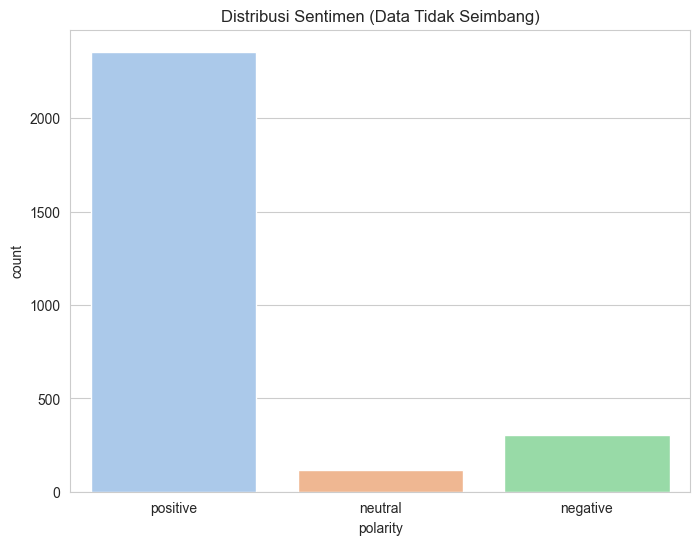

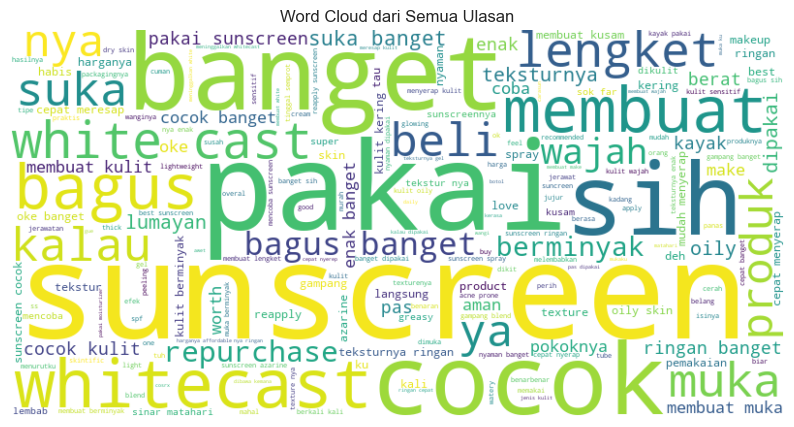


Kelas Sentimen: ['negative' 'neutral' 'positive' 'positve' 'postive']

[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Sentimen ---

--- Melatih Logistic Regression ---
F1-Score: 0.7964
              precision    recall  f1-score   support

    negative       0.29      0.50      0.37        54
     neutral       0.03      0.06      0.04        18
    positive       0.93      0.82      0.87       484
     positve       0.00      0.00      0.00         0
     postive       0.00      0.00      0.00         0

    accuracy                           0.76       556
   macro avg       0.25      0.28      0.26       556
weighted avg       0.84      0.76      0.80       556


--- Melatih Random Forest ---
F1-Score: 0.8187
              precision    recall  f1-score   support

    negative       1.00      0.04      0.07        54
     neutral       0.00      0.00

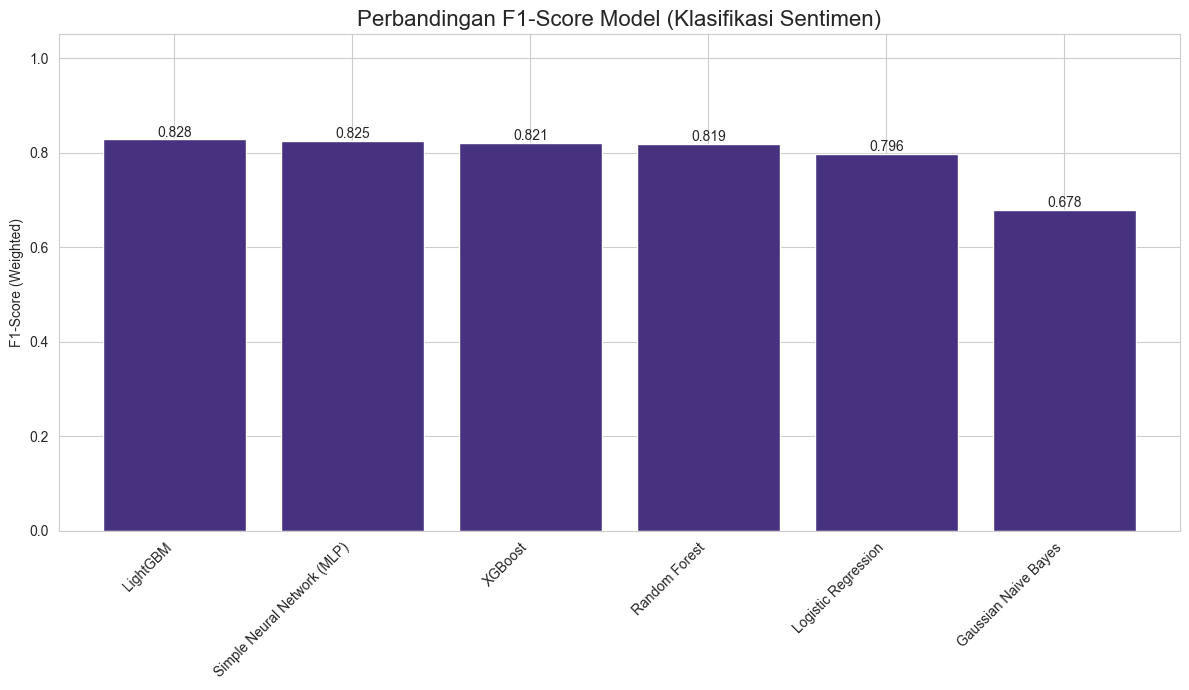

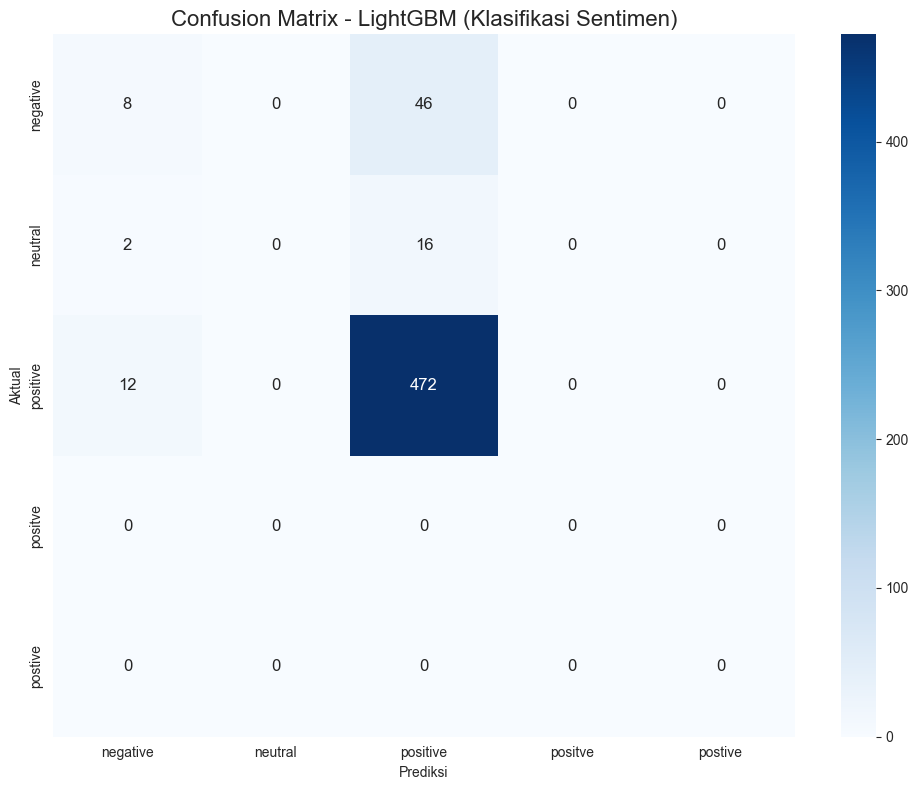


--- Analisis Kesalahan untuk Model Terbaik: LightGBM ---
Menampilkan 10 dari 76 kesalahan prediksi:
                                                                                                                                                                                                  Review Asli  \
354                                             actually ini okay suncreen tapi masih ada yang lebih bagus karena untuk berjerawag sama oily agak enggak enak di pakaj tapi untuk kerinh sensitif bagus juga.   
929   produk sunscreen yang lumayan oke tapi untuk harga menengah lah ya untuk pamakaian cocok di kulit yang sensitiv jadi yang mau coba masih oke saja, tekstur oke banget karena sangat ringan tapi afte...   
834   sunscreen mist yang aku suka karena simple terus efektif di wajah juga enggak bikin make up rusak pakai ini kalau lagi keluar-keluar saja jadi selalu ada di tas dan menurut aku ini awet banget ent...   
2243  buat harga ini termasuk pricey sih ya di kantong pelajar 

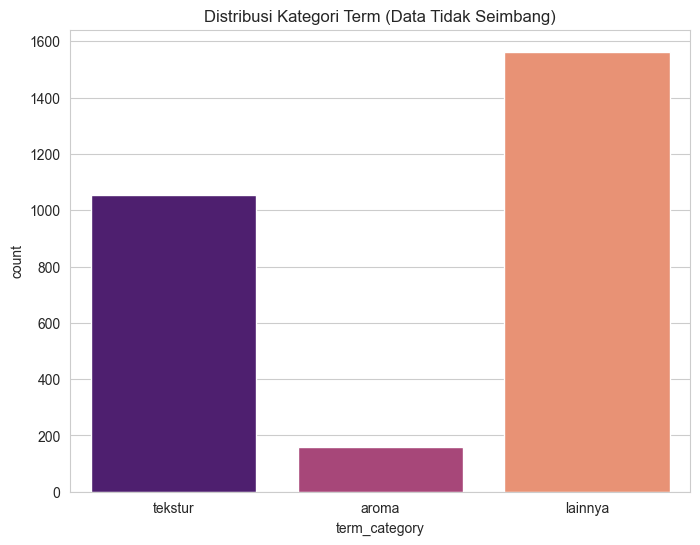


Kelas Term yang Telah Dipetakan: ['aroma' 'lainnya' 'tekstur']

[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Term Aspek ---

--- Melatih Logistic Regression ---
F1-Score: 0.5200
              precision    recall  f1-score   support

       aroma       0.18      0.25      0.21        32
     lainnya       0.63      0.56      0.59       313
     tekstur       0.44      0.49      0.46       211

    accuracy                           0.51       556
   macro avg       0.42      0.43      0.42       556
weighted avg       0.53      0.51      0.52       556


--- Melatih Random Forest ---
F1-Score: 0.3742
              precision    recall  f1-score   support

       aroma       0.00      0.00      0.00        32
     lainnya       0.51      0.63      0.56       313
     tekstur       0.19      0.12      0.15       211

    accuracy                         

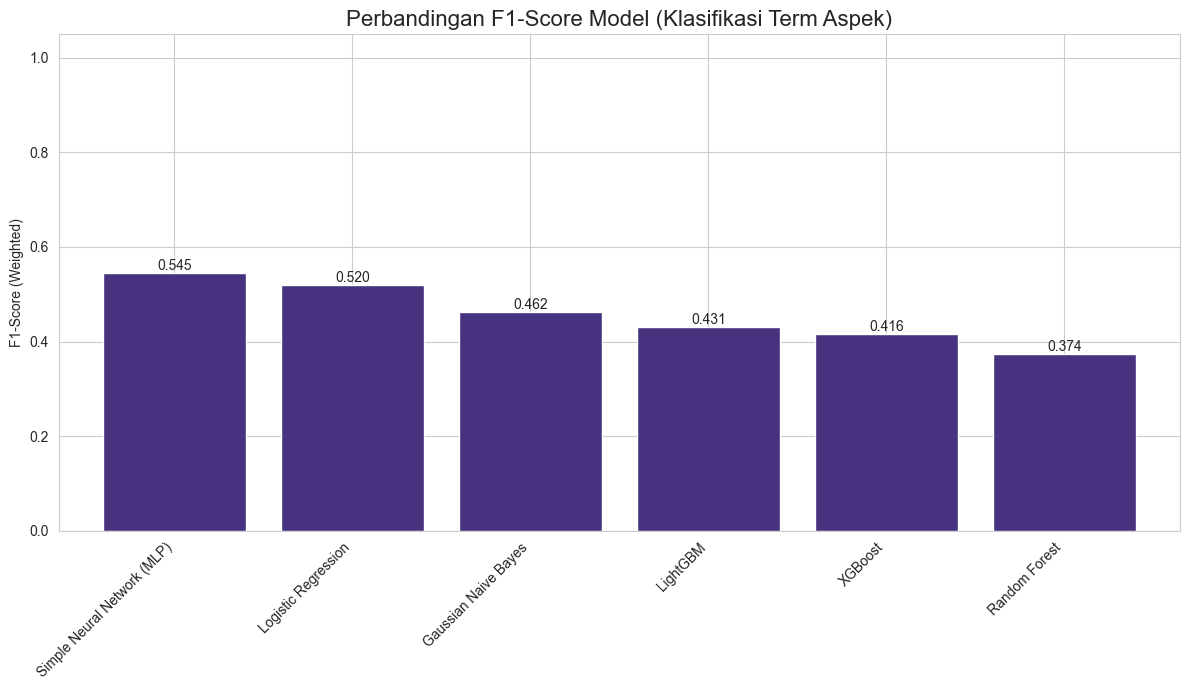

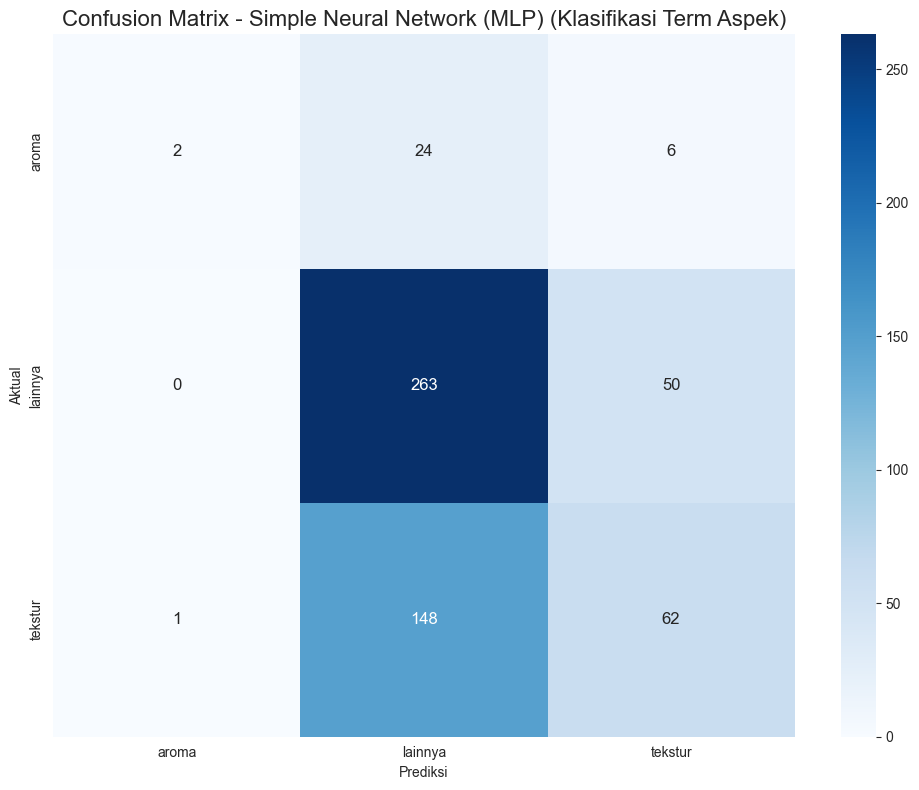


--- Analisis Kesalahan untuk Model Terbaik: Simple Neural Network (MLP) ---
Menampilkan 10 dari 229 kesalahan prediksi:
                                                                                                                                                                                                  Review Asli  \
779   aku rasa pakai carasun ini oke-oke saja sih di muka ku, enggak ada side effect yang macam-macam (kayak breakout dl), cuma memang texturenya agak kentel saja sih, dan kerasanya enggak begitu ringan...   
528                   pertama beli karena reviewnya bagus bagus banget, and this lived up tapi its hype sih. texturenya ringan banget dan itu leaves a glowy finish. worth itu banget for an affordable price   
209                                        suka sama teksturnya gel dan enggak lengket, sudah repurchase berkali kali dan ini botol ke13. bikin muka lebih lembab dan enggak bikin komedoan thankyou azarine!   
233                                   prakt

In [12]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight # Import untuk class weighting
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_data(filepath):
    """Memuat dan merestrukturisasi data."""
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_restructured.dropna(subset=['review', 'term', 'polarity'], inplace=True)
    df_restructured = df_restructured[df_restructured['term'].str.strip() != '']
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin: {len(df_restructured)}")
    return df_restructured

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks pada kolom review."""
    print("\n[Tahap 2] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 3] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        print(f"  - Memproses batch {i//batch_size + 1}/{(len(texts)//batch_size)+1}", end='\r')
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    print("\nEkstraksi embedding selesai.")
    return np.vstack(embeddings)

def train_and_evaluate(X, y, le, original_reviews, task_name=""):
    """Fungsi generik untuk melatih, mengevaluasi, dan menganalisis hasil dengan penanganan imbalance."""
    print(f"\n--- Memulai Pelatihan untuk Tugas: {task_name} ---")
    
    label_counts = pd.Series(y).value_counts()
    stratify_option = y if not (label_counts < 2).any() else None

    indices = np.arange(X.shape[0])
    X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
        X, y, indices, test_size=0.2, random_state=42, stratify=stratify_option
    )
    reviews_test = original_reviews.iloc[indices_test]

    string_labels = le.classes_
    numerical_labels = le.transform(string_labels)
    
    # --- PENANGANAN IMBALANCE: MENGHITUNG SAMPLE WEIGHTS ---
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
        "Gaussian Naive Bayes": GaussianNB(), # Naive Bayes tidak support class_weight secara langsung
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss' if len(string_labels)>2 else 'logloss'),
        "LightGBM": lgb.LGBMClassifier(random_state=42, class_weight='balanced')
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        # Terapkan sample_weight untuk model yang mendukung
        if name in ["XGBoost"]:
            model.fit(X_train, y_train, sample_weight=sample_weights)
        else:
            model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_test, y_pred, labels=numerical_labels, target_names=string_labels, zero_division=0))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred, 'labels': string_labels, 'reviews': reviews_test}
    
    visualize_and_analyze(results, best_model_info, le, task_name)

def visualize_and_analyze(all_results, best_model_info, le, task_name=""):
    """Menampilkan visualisasi hasil dan analisis kesalahan."""
    print(f"\n--- Menampilkan Visualisasi & Analisis untuk Tugas: {task_name} ---")
    
    results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title(f'Perbandingan F1-Score Model ({task_name})', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()

    best_name = best_model_info['name']
    string_labels = best_model_info['labels']
    cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'], labels=le.transform(string_labels))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=string_labels, yticklabels=string_labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {best_name} ({task_name})', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout(); plt.show()
    
    print(f"\n--- Analisis Kesalahan untuk Model Terbaik: {best_name} ---")
    y_test_labels = le.inverse_transform(best_model_info['y_test'])
    y_pred_labels = le.inverse_transform(best_model_info['y_pred'])
    
    error_df = pd.DataFrame({
        'Review Asli': best_model_info['reviews'],
        'Label Sebenarnya': y_test_labels,
        'Label Prediksi': y_pred_labels
    })
    
    errors = error_df[error_df['Label Sebenarnya'] != error_df['Label Prediksi']]
    
    if errors.empty:
        print("🎉 Selamat! Tidak ada kesalahan prediksi pada test set.")
    else:
        pd.set_option('display.max_colwidth', 200)
        print(f"Menampilkan {min(10, len(errors))} dari {len(errors)} kesalahan prediksi:")
        print(errors.head(10))

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df_base = restructure_data(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    df_processed = preprocess_text(df_base.copy())

    # --- TUGAS 1: KLASIFIKASI SENTIMEN (POSITIVE, NEGATIVE, NEUTRAL) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||")
    print("="*50)
    df_sentiment = df_processed.copy()
    
    plt.figure(figsize=(8, 6)); sns.countplot(x='polarity', data=df_sentiment, order=['positive', 'neutral', 'negative'], palette='pastel')
    plt.title('Distribusi Sentimen (Data Tidak Seimbang)'); plt.show()
    
    all_reviews_text = ' '.join(df_sentiment['review_cleaned'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews_text)
    plt.figure(figsize=(10, 7)); plt.imshow(wordcloud, interpolation='bilinear'); plt.axis('off'); plt.title('Word Cloud dari Semua Ulasan'); plt.show()

    df_sentiment['term_cleaned'] = df_sentiment['term'].apply(lambda x: ' '.join(str(x).lower().split()))
    df_sentiment['bert_input'] = df_sentiment['review_cleaned'] + " [SEP] " + df_sentiment['term_cleaned']
    
    le_sentiment = LabelEncoder()
    y_sentiment = le_sentiment.fit_transform(df_sentiment['polarity'])
    print(f"\nKelas Sentimen: {le_sentiment.classes_}")
    
    X_sentiment = get_bert_embeddings(df_sentiment['bert_input'].tolist())
    train_and_evaluate(X_sentiment, y_sentiment, le_sentiment, df_sentiment['review'], task_name="Klasifikasi Sentimen")

    # --- TUGAS 2: KLASIFIKASI TERM (TEKSTUR, AROMA, LAINNYA) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||")
    print("="*50)
    
    def map_term_to_category(term):
        term = term.lower()
        if term == 'tekstur': return 'tekstur'
        if term == 'aroma': return 'aroma'
        return 'lainnya'

    df_term = df_processed.copy()
    df_term['term_category'] = df_term['term'].apply(map_term_to_category)

    plt.figure(figsize=(8, 6)); sns.countplot(x='term_category', data=df_term, order=['tekstur', 'aroma', 'lainnya'], palette='magma')
    plt.title('Distribusi Kategori Term (Data Tidak Seimbang)'); plt.show()

    le_term = LabelEncoder()
    y_term = le_term.fit_transform(df_term['term_category'])
    print(f"\nKelas Term yang Telah Dipetakan: {le_term.classes_}")
    
    X_term = get_bert_embeddings(df_term['review_cleaned'].tolist())
    train_and_evaluate(X_term, y_term, le_term, df_term['review'], task_name="Klasifikasi Term Aspek")

    print("\n--- ✅ Semua Proses Selesai ---")

Menggunakan device: cpu

[Tahap 1] Memuat dan Merestrukturisasi Data...
Data berhasil direstrukturisasi. Jumlah data poin: 2776

[Tahap 2] Pra-pemrosesan Teks...
Pra-pemrosesan teks selesai.

|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||


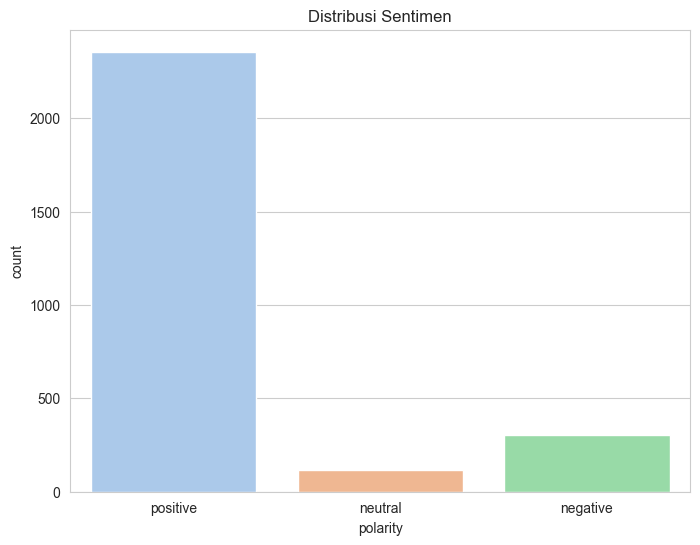

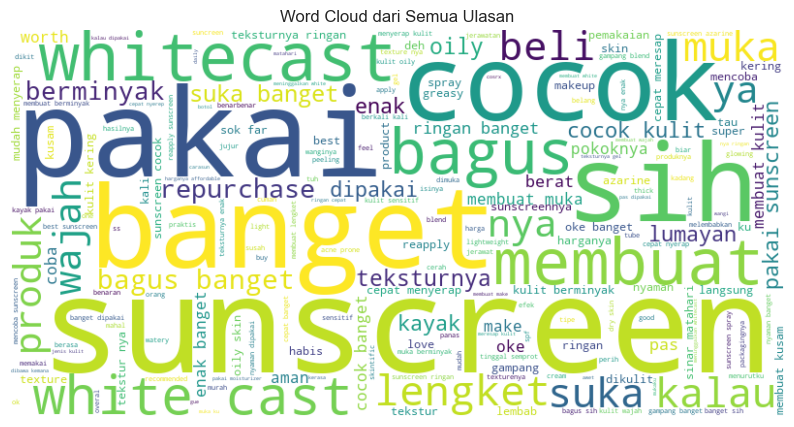


Kelas Sentimen: ['negative' 'neutral' 'positive' 'positve' 'postive']

[Tahap 3] Mengekstrak Fitur Embedding dari indobenchmark/indobert-base-p1...
  - Memproses batch 174/174
Ekstraksi embedding selesai.

--- Memulai Pelatihan untuk Tugas: Klasifikasi Sentimen ---
⚠️ Peringatan: Stratifikasi dinonaktifkan karena ada kelas dengan kurang dari 3 sampel.
Ukuran Data: Train=1943, Validation=416, Test=417

--- Melatih Logistic Regression ---
F1-Score (pada Test Set): 0.7924
              precision    recall  f1-score   support

    negative       0.29      0.51      0.37        39
     neutral       0.12      0.18      0.14        17
    positive       0.92      0.82      0.87       361
     positve       0.00      0.00      0.00         0
     postive       0.00      0.00      0.00         0

    accuracy                           0.77       417
   macro avg       0.27      0.30      0.28       417
weighted avg       0.83      0.77      0.79       417


--- Melatih Random Forest ---
F1-Sc

TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [14]:
# =================================================================================
# --- [LANGKAH 0] PERSIAPAN DAN IMPORT LIBRARY ---
# =================================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
import nltk
import torch
import warnings
import sys
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

# Tentukan device (GPU jika tersedia, jika tidak CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# =================================================================================
# --- [LANGKAH 1] FUNGSI-FUNGSI UTAMA ---
# =================================================================================

def download_nltk_data():
    """Mendownload data yang dibutuhkan oleh NLTK."""
    try:
        stopwords.words('indonesian')
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Mendownload data NLTK (stopwords, punkt)...")
        nltk.download('stopwords', quiet=True)
        nltk.download('punkt', quiet=True)
        print("Download selesai.")

def restructure_data(filepath):
    """Memuat dan merestrukturisasi data."""
    print("\n[Tahap 1] Memuat dan Merestrukturisasi Data...")
    try:
        df = pd.read_csv(filepath, delimiter=';', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
        
    new_data = []
    for _, row in df.iterrows():
        review_text = row['review']
        try:
            aspect_str = row['aspect_term_sentiment'].strip('"')
            aspects = ast.literal_eval(aspect_str)
            if isinstance(aspects, list):
                for aspect in aspects:
                    if 'term' in aspect and 'polarity' in aspect:
                        new_data.append({'review': review_text, 'term': aspect['term'], 'polarity': aspect['polarity']})
        except (ValueError, SyntaxError, TypeError):
            continue
            
    df_restructured = pd.DataFrame(new_data)
    df_restructured.dropna(subset=['review', 'term', 'polarity'], inplace=True)
    df_restructured = df_restructured[df_restructured['term'].str.strip() != '']
    
    print(f"Data berhasil direstrukturisasi. Jumlah data poin: {len(df_restructured)}")
    return df_restructured

def preprocess_text(df):
    """Melakukan pra-pemrosesan teks pada kolom review."""
    print("\n[Tahap 2] Pra-pemrosesan Teks...")
    slang_dict = {'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'krn': 'karena', 'utk': 'untuk', 'bgt': 'banget', 'lg': 'lagi', 'aja': 'saja', 'sm': 'sama', 'udah': 'sudah', 'sdh': 'sudah', 'blm': 'belum', 'emg': 'memang', 'kalo': 'kalau', 'dgn': 'dengan', 'dr': 'dari', 'bikin': 'membuat', 'jujurly':'jujur', 'tp': 'tapi', 'tdk': 'tidak'}
    stop_words = set(stopwords.words('indonesian'))

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        tokens = word_tokenize(text)
        processed_tokens = [slang_dict.get(word, word) for word in tokens if word not in stop_words and len(word) > 1]
        return " ".join(processed_tokens)

    df['review_cleaned'] = df['review'].apply(clean_text)
    print("Pra-pemrosesan teks selesai.")
    return df

def get_bert_embeddings(texts, model_name="indobenchmark/indobert-base-p1"):
    """Mengekstrak embedding [CLS] dari model BERT."""
    print(f"\n[Tahap 3] Mengekstrak Fitur Embedding dari {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    embeddings = []

    batch_size = 16
    for i in range(0, len(texts), batch_size):
        print(f"  - Memproses batch {i//batch_size + 1}/{(len(texts)//batch_size)+1}", end='\r')
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
            
    print("\nEkstraksi embedding selesai.")
    return np.vstack(embeddings)

def train_and_evaluate(X, y, le, original_reviews, task_name=""):
    """Fungsi generik untuk melatih, mengevaluasi, dan menganalisis hasil."""
    print(f"\n--- Memulai Pelatihan untuk Tugas: {task_name} ---")
    
    label_counts = pd.Series(y).value_counts()
    stratify_option = y if not (label_counts < 3).any() else None
    if stratify_option is None:
        print("⚠️ Peringatan: Stratifikasi dinonaktifkan karena ada kelas dengan kurang dari 3 sampel.")

    indices = np.arange(X.shape[0])
    
    X_train, X_temp, y_train, y_temp, indices_train, indices_temp = train_test_split(
        X, y, indices, test_size=0.3, random_state=42, stratify=stratify_option
    )
    
    temp_label_counts = pd.Series(y_temp).value_counts()
    temp_stratify_option = y_temp if not (temp_label_counts < 2).any() else None
    
    X_val, X_test, y_val, y_test, indices_val, indices_test = train_test_split(
        X_temp, y_temp, indices_temp, test_size=0.5, random_state=42, stratify=temp_stratify_option
    )

    reviews_test = original_reviews.iloc[indices_test]
    print(f"Ukuran Data: Train={len(X_train)}, Validation={len(X_val)}, Test={len(X_test)}")

    string_labels = le.classes_
    numerical_labels = le.transform(string_labels)
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
        "Gaussian Naive Bayes": GaussianNB(),
        "Simple Neural Network (MLP)": MLPClassifier(random_state=42, max_iter=500, early_stopping=True, validation_fraction=0.15),
        "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss' if len(string_labels)>2 else 'logloss'),
        "LightGBM": lgb.LGBMClassifier(random_state=42, class_weight='balanced')
    }
    
    results = {}
    best_f1 = -1
    best_model_info = {}

    for name, model in models.items():
        print(f"\n--- Melatih {name} ---")
        if name == "XGBoost":
            # --- PERBAIKAN: Menggunakan early_stopping_rounds ---
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=10, sample_weight=sample_weights, verbose=False)
        elif name == "LightGBM":
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(10, verbose=False)])
        elif name == "Simple Neural Network (MLP)":
             model.fit(X_train, y_train) # MLP menggunakan validation set-nya sendiri dari data train
        else:
            model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"F1-Score (pada Test Set): {f1:.4f}")
        print(classification_report(y_test, y_pred, labels=numerical_labels, target_names=string_labels, zero_division=0))
        results[name] = f1

        if f1 > best_f1:
            best_f1 = f1
            best_model_info = {'name': name, 'y_test': y_test, 'y_pred': y_pred, 'labels': string_labels, 'reviews': reviews_test}
    
    visualize_and_analyze(results, best_model_info, le, task_name)

def visualize_and_analyze(all_results, best_model_info, le, task_name=""):
    """Menampilkan visualisasi hasil dan analisis kesalahan."""
    print(f"\n--- Menampilkan Visualisasi & Analisis untuk Tugas: {task_name} ---")
    
    results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['F1-Score']).sort_values('F1-Score', ascending=False)
    plt.figure(figsize=(12, 7)); sns.set_palette("viridis")
    ax = results_df['F1-Score'].plot(kind='bar', width=0.8)
    plt.title(f'Perbandingan F1-Score Model ({task_name})', fontsize=16); plt.ylabel('F1-Score (Weighted)'); plt.xticks(rotation=45, ha='right'); plt.ylim(0, 1.05)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(); plt.show()

    best_name = best_model_info['name']
    string_labels = best_model_info['labels']
    cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'], labels=le.transform(string_labels))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=string_labels, yticklabels=string_labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {best_name} ({task_name})', fontsize=16); plt.xlabel('Prediksi'); plt.ylabel('Aktual')
    plt.tight_layout(); plt.show()
    
    print(f"\n--- Analisis Kesalahan untuk Model Terbaik: {best_name} ---")
    y_test_labels = le.inverse_transform(best_model_info['y_test'])
    y_pred_labels = le.inverse_transform(best_model_info['y_pred'])
    
    error_df = pd.DataFrame({
        'Review Asli': best_model_info['reviews'],
        'Label Sebenarnya': y_test_labels,
        'Label Prediksi': y_pred_labels
    })
    
    errors = error_df[error_df['Label Sebenarnya'] != error_df['Label Prediksi']]
    
    if errors.empty:
        print("🎉 Selamat! Tidak ada kesalahan prediksi pada test set.")
    else:
        pd.set_option('display.max_colwidth', 200)
        print(f"Menampilkan {min(10, len(errors))} dari {len(errors)} kesalahan prediksi:")
        print(errors.head(10))

# =================================================================================
# --- [LANGKAH 2] ALUR EKSEKUSI UTAMA ---
# =================================================================================
if __name__ == "__main__":
    download_nltk_data()
    file_path = "responsi_data.csv"
    
    try:
        df_base = restructure_data(file_path)
    except FileNotFoundError:
        print(f"\n❌ ERROR: File tidak ditemukan di path '{file_path}'")
        sys.exit()

    df_processed = preprocess_text(df_base.copy())

    # --- TUGAS 1: KLASIFIKASI SENTIMEN (POSITIVE, NEGATIVE, NEUTRAL) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 1: KLASIFIKASI SENTIMEN ||")
    print("="*50)
    df_sentiment = df_processed.copy()
    
    plt.figure(figsize=(8, 6)); sns.countplot(x='polarity', data=df_sentiment, order=['positive', 'neutral', 'negative'], palette='pastel')
    plt.title('Distribusi Sentimen'); plt.show()
    
    all_reviews_text = ' '.join(df_sentiment['review_cleaned'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews_text)
    plt.figure(figsize=(10, 7)); plt.imshow(wordcloud, interpolation='bilinear'); plt.axis('off'); plt.title('Word Cloud dari Semua Ulasan'); plt.show()

    df_sentiment['term_cleaned'] = df_sentiment['term'].apply(lambda x: ' '.join(str(x).lower().split()))
    df_sentiment['bert_input'] = df_sentiment['review_cleaned'] + " [SEP] " + df_sentiment['term_cleaned']
    
    le_sentiment = LabelEncoder()
    y_sentiment = le_sentiment.fit_transform(df_sentiment['polarity'])
    print(f"\nKelas Sentimen: {le_sentiment.classes_}")
    
    X_sentiment = get_bert_embeddings(df_sentiment['bert_input'].tolist())
    train_and_evaluate(X_sentiment, y_sentiment, le_sentiment, df_sentiment['review'], task_name="Klasifikasi Sentimen")

    # --- TUGAS 2: KLASIFIKASI TERM (TEKSTUR, AROMA, LAINNYA) ---
    print("\n" + "="*50)
    print("|| MEMULAI TUGAS 2: KLASIFIKASI TERM ASPEK ||")
    print("="*50)
    
    def map_term_to_category(term):
        term = term.lower()
        if term == 'tekstur': return 'tekstur'
        if term == 'aroma': return 'aroma'
        return 'lainnya'

    df_term = df_processed.copy()
    df_term['term_category'] = df_term['term'].apply(map_term_to_category)

    plt.figure(figsize=(8, 6)); sns.countplot(x='term_category', data=df_term, order=['tekstur', 'aroma', 'lainnya'], palette='magma')
    plt.title('Distribusi Kategori Term'); plt.show()

    le_term = LabelEncoder()
    y_term = le_term.fit_transform(df_term['term_category'])
    print(f"\nKelas Term yang Telah Dipetakan: {le_term.classes_}")
    
    X_term = get_bert_embeddings(df_term['review_cleaned'].tolist())
    train_and_evaluate(X_term, y_term, le_term, df_term['review'], task_name="Klasifikasi Term Aspek")

    print("\n--- ✅ Semua Proses Selesai ---")